# Import Liberaries

In [1]:
import pandas as pd

pd.set_option('display.max_columns', None)

pd.set_option('display.max_rows', None)

import numpy as np

import matplotlib.pyplot as plt

import matplotlib.gridspec as gridspec

import seaborn as sns

import plotly.express as px

import plotly.graph_objects as go

from plotly.subplots import make_subplots

import plotly.tools as tls
import plotly.offline as py      


import warnings

warnings.filterwarnings("ignore")

# Read Data

In [2]:
df = pd.read_csv(
    'loan.csv',
    nrows=50000,
    engine='python',
    on_bad_lines='skip',
    low_memory=True
)

In [3]:
# ================================
# FIX TARGET (FINAL CLEAN VERSION)
# ================================

# Keep only binary classes
df = df[df['loan_status'].isin(['Fully Paid', 'Charged Off'])]

# Convert to binary
df['loan_status'] = df['loan_status'].map({
    'Fully Paid': 0,
    'Charged Off': 1
})

print(df['loan_status'].value_counts())

loan_status
0    34854
1     6196
Name: count, dtype: int64


In [4]:
print(df.shape)
print(df.columns)

(41050, 74)
Index(['id', 'member_id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv',
       'term', 'int_rate', 'installment', 'grade', 'sub_grade', 'emp_title',
       'emp_length', 'home_ownership', 'annual_inc', 'verification_status',
       'issue_d', 'loan_status', 'pymnt_plan', 'url', 'desc', 'purpose',
       'title', 'zip_code', 'addr_state', 'dti', 'delinq_2yrs',
       'earliest_cr_line', 'inq_last_6mths', 'mths_since_last_delinq',
       'mths_since_last_record', 'open_acc', 'pub_rec', 'revol_bal',
       'revol_util', 'total_acc', 'initial_list_status', 'out_prncp',
       'out_prncp_inv', 'total_pymnt', 'total_pymnt_inv', 'total_rec_prncp',
       'total_rec_int', 'total_rec_late_fee', 'recoveries',
       'collection_recovery_fee', 'last_pymnt_d', 'last_pymnt_amnt',
       'next_pymnt_d', 'last_credit_pull_d', 'collections_12_mths_ex_med',
       'mths_since_last_major_derog', 'policy_code', 'application_type',
       'annual_inc_joint', 'dti_joint', 'verification_status_

In [5]:
df.head(3)

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,url,desc,purpose,title,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,next_pymnt_d,last_credit_pull_d,collections_12_mths_ex_med,mths_since_last_major_derog,policy_code,application_type,annual_inc_joint,dti_joint,verification_status_joint,acc_now_delinq,tot_coll_amt,tot_cur_bal,open_acc_6m,open_il_6m,open_il_12m,open_il_24m,mths_since_rcnt_il,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m
0,1077501,1296599,5000.0,5000.0,4975.0,36 months,10.65,162.87,B,B2,NaN,10+ years,RENT,24000.0,Verified,Dec-2011,0,n,https://www.lendingclub.com/browse/loanDetail....,Borrower added on 12/22/11 > I need to upgra...,credit_card,Computer,860xx,AZ,27.65,0.0,Jan-1985,1.0,NaN,NaN,3.0,0.0,13648.0,83.7,9.0,f,0.0,0.0,5861.071414,5831.78,5000.00,861.07,0.0,0.00,0.00,Jan-2015,171.62,NaN,Jan-2016,0.0,NaN,1.0,INDIVIDUAL,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1077430,1314167,2500.0,2500.0,2500.0,60 months,15.27,59.83,C,C4,Ryder,< 1 year,RENT,30000.0,Source Verified,Dec-2011,1,n,https://www.lendingclub.com/browse/loanDetail....,Borrower added on 12/22/11 > I plan to use t...,car,bike,309xx,GA,1.00,0.0,Apr-1999,5.0,NaN,NaN,3.0,0.0,1687.0,9.4,4.0,f,0.0,0.0,1008.710000,1008.71,456.46,435.17,0.0,117.08,1.11,Apr-2013,119.66,NaN,Sep-2013,0.0,NaN,1.0,INDIVIDUAL,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1077175,1313524,2400.0,2400.0,2400.0,36 months,15.96,84.33,C,C5,NaN,10+ years,RENT,12252.0,Not Verified,Dec-2011,0,n,https://www.lendingclub.com/browse/loanDetail....,NaN,small_business,real estate business,606xx,IL,8.72,0.0,Nov-2001,2.0,NaN,NaN,2.0,0.0,2956.0,98.5,10.0,f,0.0,0.0,3003.653644,3003.65,2400.00,603.65,0.0,0.00,0.00,Jun-2014,649.91,NaN,Jan-2016,0.0,NaN,1.0,INDIVIDUAL,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Data Preprocessing

In [6]:
null_percentages = df.isnull().mean() * 100



for column, percentage in null_percentages.items():

  if percentage:

    print({column: [round(percentage, 5), df[column].dtype]})

{'emp_title': [6.11206, dtype('O')]}
{'emp_length': [2.75518, dtype('O')]}
{'desc': [35.15469, dtype('O')]}
{'title': [0.0268, dtype('O')]}
{'mths_since_last_delinq': [63.44702, dtype('float64')]}
{'mths_since_last_record': [92.23143, dtype('float64')]}
{'revol_util': [0.12424, dtype('float64')]}
{'last_pymnt_d': [0.18027, dtype('O')]}
{'next_pymnt_d': [100.0, dtype('O')]}
{'last_credit_pull_d': [0.00487, dtype('O')]}
{'collections_12_mths_ex_med': [0.13642, dtype('float64')]}
{'mths_since_last_major_derog': [97.95128, dtype('float64')]}
{'annual_inc_joint': [100.0, dtype('float64')]}
{'dti_joint': [100.0, dtype('float64')]}
{'verification_status_joint': [100.0, dtype('float64')]}
{'tot_coll_amt': [91.90012, dtype('float64')]}
{'tot_cur_bal': [91.90012, dtype('float64')]}
{'open_acc_6m': [100.0, dtype('float64')]}
{'open_il_6m': [100.0, dtype('float64')]}
{'open_il_12m': [100.0, dtype('float64')]}
{'open_il_24m': [100.0, dtype('float64')]}
{'mths_since_rcnt_il': [100.0, dtype('float64'

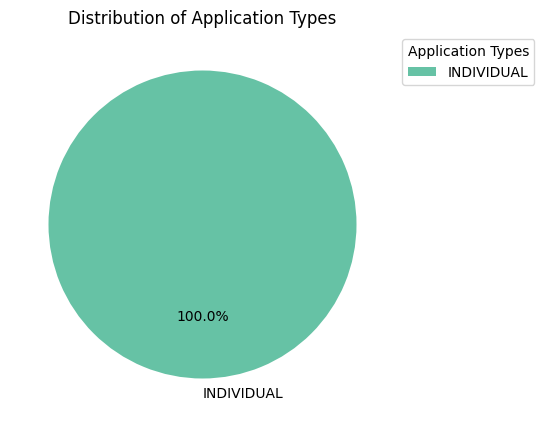

In [7]:
# Get the value counts for 'application_type'
application_type_counts = df['application_type'].value_counts()

# Set up the figure
plt.figure(figsize=(8, 5))

# Create the pie chart
plt.pie(application_type_counts.values, labels=application_type_counts.index, autopct='%1.1f%%', 
        startangle=90, colors=sns.color_palette('Set2'))

# Add a legend
plt.legend(application_type_counts.index, title="Application Types", bbox_to_anchor=(1, 1), loc="best")

# Set title
plt.title('Distribution of Application Types')

# Display the plot
plt.show()

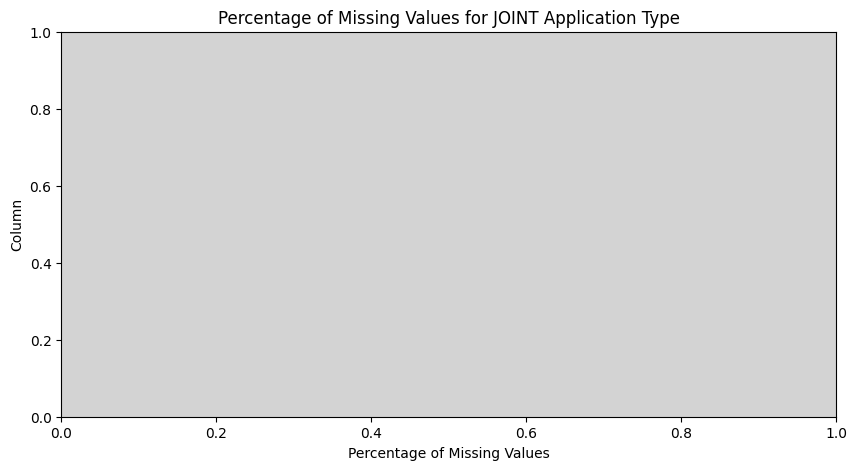

In [8]:
# Get the percentage of missing values for the 'JOINT' application type
joint_na_percentages = df[df['application_type'] == 'JOINT'].isna().mean() * 100

# Filter columns with more than 5% missing values
joint_na_percentages = joint_na_percentages[joint_na_percentages > 5]

# Set up the figure
plt.figure(figsize=(10, 5))

# Create the bar plot using Seaborn
sns.barplot(x=joint_na_percentages.values, y=joint_na_percentages.index, palette='Set2')

# Add labels and title
plt.xlabel('Percentage of Missing Values')
plt.ylabel('Column')
plt.title('Percentage of Missing Values for JOINT Application Type')

# Customize plot and background color
plt.gca().set_facecolor('lightgray')  # Background color inside the plot

# Show the plot
plt.show()

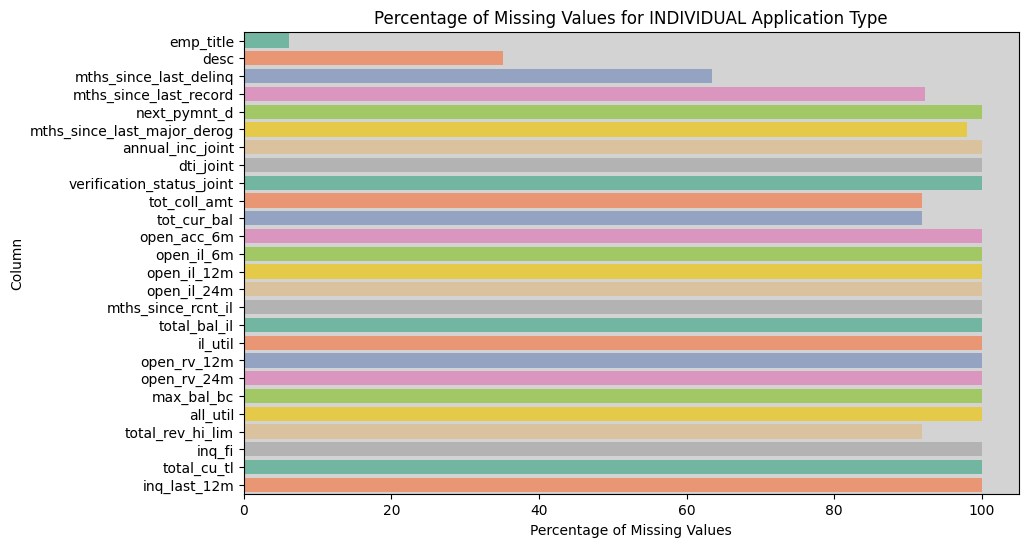

In [9]:
# Get the percentage of missing values for the 'INDIVIDUAL' application type
individual_na_percentages = df[df['application_type'] == 'INDIVIDUAL'].isna().mean() * 100

# Filter columns with more than 5% missing values
individual_na_percentages = individual_na_percentages[individual_na_percentages > 5]

# Set up the figure
plt.figure(figsize=(10, 6))

# Create the bar plot using Seaborn
sns.barplot(x=individual_na_percentages.values, y=individual_na_percentages.index, palette='Set2')

# Add labels and title
plt.xlabel('Percentage of Missing Values')
plt.ylabel('Column')
plt.title('Percentage of Missing Values for INDIVIDUAL Application Type')

# Customize plot and background color
plt.gca().set_facecolor('lightgray')  # Background color inside the plot

# Show the plot
plt.show()

In [10]:
df.shape

(41050, 74)

drop JOINT records to keep all values for INDIVIDUAL application_type

In [11]:
df = df[df['application_type'] != 'JOINT']

In [12]:
df.shape

(41050, 74)

In [13]:
columns_to_drop = [i for i in df.columns if 'joint' in i]

columns_to_drop.append('application_type')

In [14]:
df.drop(columns=columns_to_drop, inplace=True)

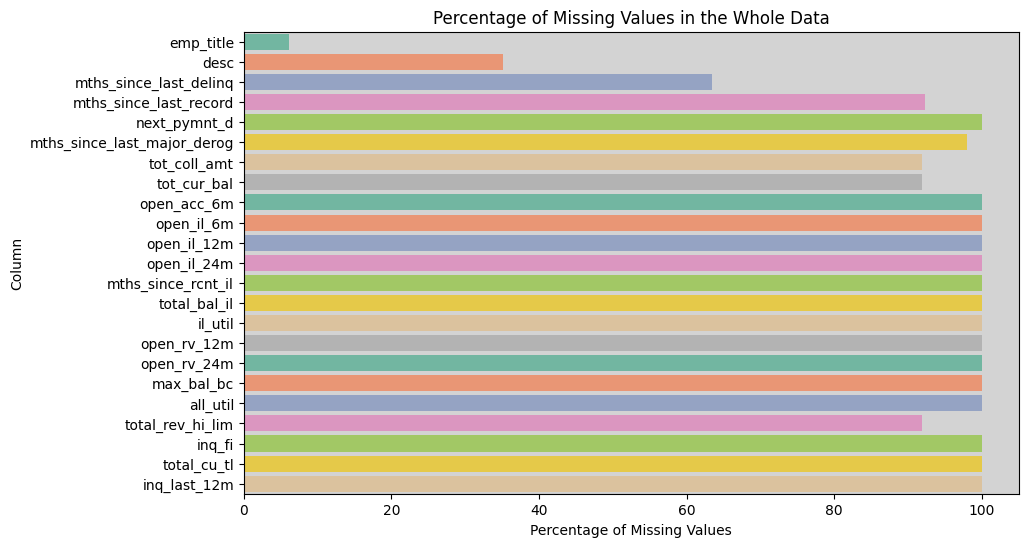

In [15]:
# Get the percentage of missing values for the entire DataFrame
na_percentages = df.isna().mean() * 100

# Filter columns with more than 5% missing values
na_percentages = na_percentages[na_percentages > 5]

# Set up the figure
plt.figure(figsize=(10, 6))

# Create the bar plot using Seaborn
sns.barplot(x=na_percentages.values, y=na_percentages.index, palette='Set2')

# Add labels and title
plt.xlabel('Percentage of Missing Values')
plt.ylabel('Column')
plt.title('Percentage of Missing Values in the Whole Data')

# Customize plot and background color
plt.gca().set_facecolor('lightgray')  # Background color inside the plot

# Show the plot
plt.show()

In [16]:
columns_to_drop = []

for i in df.columns:

  if df[i].isna().mean()*100 > 20:

    columns_to_drop.append(i)

In [17]:
df.drop(columns=columns_to_drop, inplace=True)

In [18]:
for i in df.columns:

  print({i: df[i].nunique()})

{'id': 41050}
{'member_id': 41050}
{'loan_amnt': 897}
{'funded_amnt': 1031}
{'funded_amnt_inv': 7981}
{'term': 2}
{'int_rate': 395}
{'installment': 16012}
{'grade': 7}
{'sub_grade': 35}
{'emp_title': 29667}
{'emp_length': 11}
{'home_ownership': 5}
{'annual_inc': 5392}
{'verification_status': 3}
{'issue_d': 56}
{'loan_status': 2}
{'pymnt_plan': 2}
{'url': 41050}
{'purpose': 14}
{'title': 19841}
{'zip_code': 832}
{'addr_state': 50}
{'dti': 3063}
{'delinq_2yrs': 12}
{'earliest_cr_line': 551}
{'inq_last_6mths': 9}
{'open_acc': 42}
{'pub_rec': 8}
{'revol_bal': 22219}
{'revol_util': 1091}
{'total_acc': 82}
{'initial_list_status': 2}
{'out_prncp': 1}
{'out_prncp_inv': 1}
{'total_pymnt': 40665}
{'total_pymnt_inv': 40380}
{'total_rec_prncp': 7976}
{'total_rec_int': 38566}
{'total_rec_late_fee': 1870}
{'recoveries': 4298}
{'collection_recovery_fee': 2878}
{'last_pymnt_d': 97}
{'last_pymnt_amnt': 36815}
{'last_credit_pull_d': 102}
{'collections_12_mths_ex_med': 2}
{'policy_code': 1}
{'acc_now_del

In [19]:
for i in df.columns:

    if df[i].nunique() < 10:

        print({i: df[i].value_counts()})

{'term': term
36 months    31641
60 months     9409
Name: count, dtype: int64}
{'grade': grade
B    12425
A    10463
C     8550
D     5515
E     2782
F     1003
G      312
Name: count, dtype: int64}
{'home_ownership': home_ownership
RENT        19391
MORTGAGE    18364
OWN          3194
OTHER          98
NONE            3
Name: count, dtype: int64}
{'verification_status': verification_status
Not Verified       17362
Verified           13247
Source Verified    10441
Name: count, dtype: int64}
{'loan_status': loan_status
0    34854
1     6196
Name: count, dtype: int64}
{'pymnt_plan': pymnt_plan
n    41048
y        2
Name: count, dtype: int64}
{'inq_last_6mths': inq_last_6mths
0.0    19742
1.0    11470
2.0     6037
3.0     3154
4.0      366
5.0      169
6.0       66
7.0       34
8.0       12
Name: count, dtype: int64}
{'pub_rec': pub_rec
0.0    38531
1.0     2391
2.0       91
3.0       24
4.0        9
5.0        2
6.0        1
9.0        1
Name: count, dtype: int64}
{'initial_list_status':

In [20]:
df.drop(columns=['pymnt_plan', 'policy_code', 'acc_now_delinq'], inplace=True)

In [21]:
df.head(3)

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,url,purpose,title,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,inq_last_6mths,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,last_credit_pull_d,collections_12_mths_ex_med
0,1077501,1296599,5000.0,5000.0,4975.0,36 months,10.65,162.87,B,B2,NaN,10+ years,RENT,24000.0,Verified,Dec-2011,0,https://www.lendingclub.com/browse/loanDetail....,credit_card,Computer,860xx,AZ,27.65,0.0,Jan-1985,1.0,3.0,0.0,13648.0,83.7,9.0,f,0.0,0.0,5861.071414,5831.78,5000.00,861.07,0.0,0.00,0.00,Jan-2015,171.62,Jan-2016,0.0
1,1077430,1314167,2500.0,2500.0,2500.0,60 months,15.27,59.83,C,C4,Ryder,< 1 year,RENT,30000.0,Source Verified,Dec-2011,1,https://www.lendingclub.com/browse/loanDetail....,car,bike,309xx,GA,1.00,0.0,Apr-1999,5.0,3.0,0.0,1687.0,9.4,4.0,f,0.0,0.0,1008.710000,1008.71,456.46,435.17,0.0,117.08,1.11,Apr-2013,119.66,Sep-2013,0.0
2,1077175,1313524,2400.0,2400.0,2400.0,36 months,15.96,84.33,C,C5,NaN,10+ years,RENT,12252.0,Not Verified,Dec-2011,0,https://www.lendingclub.com/browse/loanDetail....,small_business,real estate business,606xx,IL,8.72,0.0,Nov-2001,2.0,2.0,0.0,2956.0,98.5,10.0,f,0.0,0.0,3003.653644,3003.65,2400.00,603.65,0.0,0.00,0.00,Jun-2014,649.91,Jan-2016,0.0


In [22]:
df[['grade', 'sub_grade']].head(5)

,grade,sub_grade
0,B,B2
1,C,C4
2,C,C5
3,C,C1
5,A,A4


In [23]:
df['grade'].unique()

array(['B', 'C', 'A', 'E', 'F', 'D', 'G'], dtype=object)

In [24]:
sub_grades = df['sub_grade'].unique()

sub_grades.sort()

sub_grades

array(['A1', 'A2', 'A3', 'A4', 'A5', 'B1', 'B2', 'B3', 'B4', 'B5', 'C1',
       'C2', 'C3', 'C4', 'C5', 'D1', 'D2', 'D3', 'D4', 'D5', 'E1', 'E2',
       'E3', 'E4', 'E5', 'F1', 'F2', 'F3', 'F4', 'F5', 'G1', 'G2', 'G3',
       'G4', 'G5'], dtype=object)

In [25]:
df.drop(columns=['id', 'member_id', 'url', 'issue_d', 'earliest_cr_line', 'grade', 'last_credit_pull_d'], inplace=True)

In [26]:
df.shape

(41050, 38)

In [27]:
df.head(3)

,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,loan_status,purpose,title,zip_code,addr_state,dti,delinq_2yrs,inq_last_6mths,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,collections_12_mths_ex_med
0,5000.0,5000.0,4975.0,36 months,10.65,162.87,B2,NaN,10+ years,RENT,24000.0,Verified,0,credit_card,Computer,860xx,AZ,27.65,0.0,1.0,3.0,0.0,13648.0,83.7,9.0,f,0.0,0.0,5861.071414,5831.78,5000.00,861.07,0.0,0.00,0.00,Jan-2015,171.62,0.0
1,2500.0,2500.0,2500.0,60 months,15.27,59.83,C4,Ryder,< 1 year,RENT,30000.0,Source Verified,1,car,bike,309xx,GA,1.00,0.0,5.0,3.0,0.0,1687.0,9.4,4.0,f,0.0,0.0,1008.710000,1008.71,456.46,435.17,0.0,117.08,1.11,Apr-2013,119.66,0.0
2,2400.0,2400.0,2400.0,36 months,15.96,84.33,C5,NaN,10+ years,RENT,12252.0,Not Verified,0,small_business,real estate business,606xx,IL,8.72,0.0,2.0,2.0,0.0,2956.0,98.5,10.0,f,0.0,0.0,3003.653644,3003.65,2400.00,603.65,0.0,0.00,0.00,Jun-2014,649.91,0.0


In [28]:
df.drop(columns=['emp_title', 'title', 'zip_code', 'addr_state', 'last_pymnt_d'], inplace=True)

In [29]:
df.shape

(41050, 33)

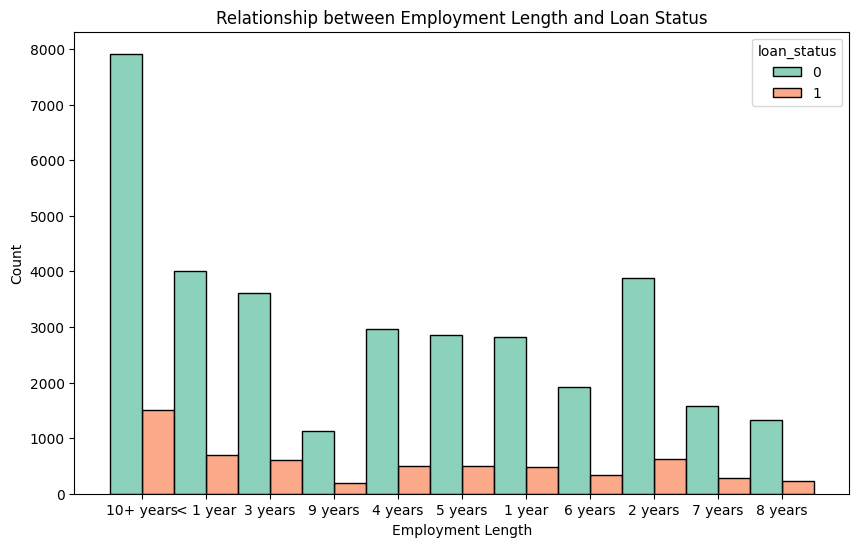

In [30]:
# Set up the figure
plt.figure(figsize=(10, 6))

# Create the histogram using Seaborn
sns.histplot(data=df, x="emp_length", hue="loan_status", multiple="dodge", palette='Set2')

# Add title and axis labels
plt.title("Relationship between Employment Length and Loan Status")
plt.xlabel("Employment Length")
plt.ylabel("Count")

# Show the plot
plt.show()

In [31]:
df.drop(columns=['emp_length'], inplace=True)

In [32]:
importante_features = df.columns

In [33]:
len(importante_features)

32

In [34]:
terms = pd.read_excel('LCDataDictionary.xlsx')

In [35]:
terms.columns

Index(['LoanStatNew', 'Description'], dtype='object')

In [36]:
feature_description = terms[terms['LoanStatNew'].isin(importante_features)][['LoanStatNew', 'Description']]

In [37]:
feature_description.reset_index(drop=True, inplace=True)

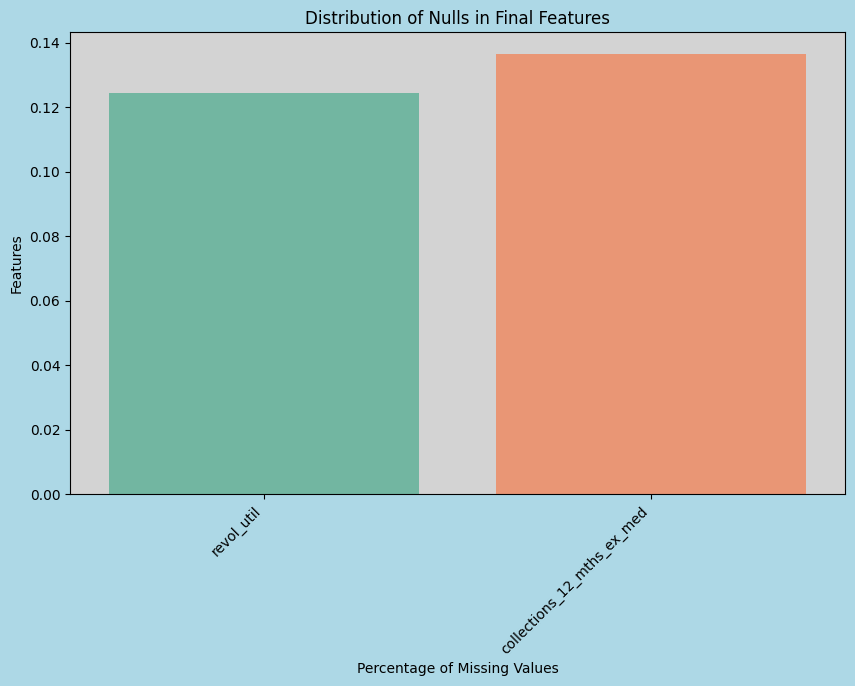

In [38]:
# Get the percentage of missing values for the entire DataFrame
na_percentages = df.isna().mean() * 100

# Filter columns with any missing values
na_percentages = na_percentages[na_percentages > 0]

# Set up the figure
plt.figure(figsize=(10, 6))

# Create the bar plot using Seaborn
sns.barplot(y=na_percentages.values, x=na_percentages.index, palette='Set2')

# Add labels and title
plt.xlabel('Percentage of Missing Values')
plt.ylabel('Features')
plt.title('Distribution of Nulls in Final Features')

# Rotate x-axis labels
plt.xticks(rotation=45, ha='right')  # Rotate labels and align them to the right

# Customize background color
plt.gca().set_facecolor('lightgray')  # Background color inside the plot
plt.gcf().set_facecolor('lightblue')  # Figure background color

# Display the plot
plt.show()

In [39]:
df[na_percentages.index].info()

<class 'pandas.core.frame.DataFrame'>
Index: 41050 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   revol_util                  40999 non-null  float64
 1   collections_12_mths_ex_med  40994 non-null  float64
dtypes: float64(2)
memory usage: 962.1 KB


In [40]:
na_percentages

revol_util                    0.124239
collections_12_mths_ex_med    0.136419
dtype: float64

In [41]:
print(df.shape)

for i in na_percentages.index:

  if na_percentages[i] < 1:

    df.dropna(subset=[i], inplace=True)

print(df.shape)

(41050, 32)
(40943, 32)


## EDA and Visualizations

In [42]:
importante_features

Index(['loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'term', 'int_rate',
       'installment', 'sub_grade', 'home_ownership', 'annual_inc',
       'verification_status', 'loan_status', 'purpose', 'dti', 'delinq_2yrs',
       'inq_last_6mths', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util',
       'total_acc', 'initial_list_status', 'out_prncp', 'out_prncp_inv',
       'total_pymnt', 'total_pymnt_inv', 'total_rec_prncp', 'total_rec_int',
       'total_rec_late_fee', 'recoveries', 'collection_recovery_fee',
       'last_pymnt_amnt', 'collections_12_mths_ex_med'],
      dtype='object')

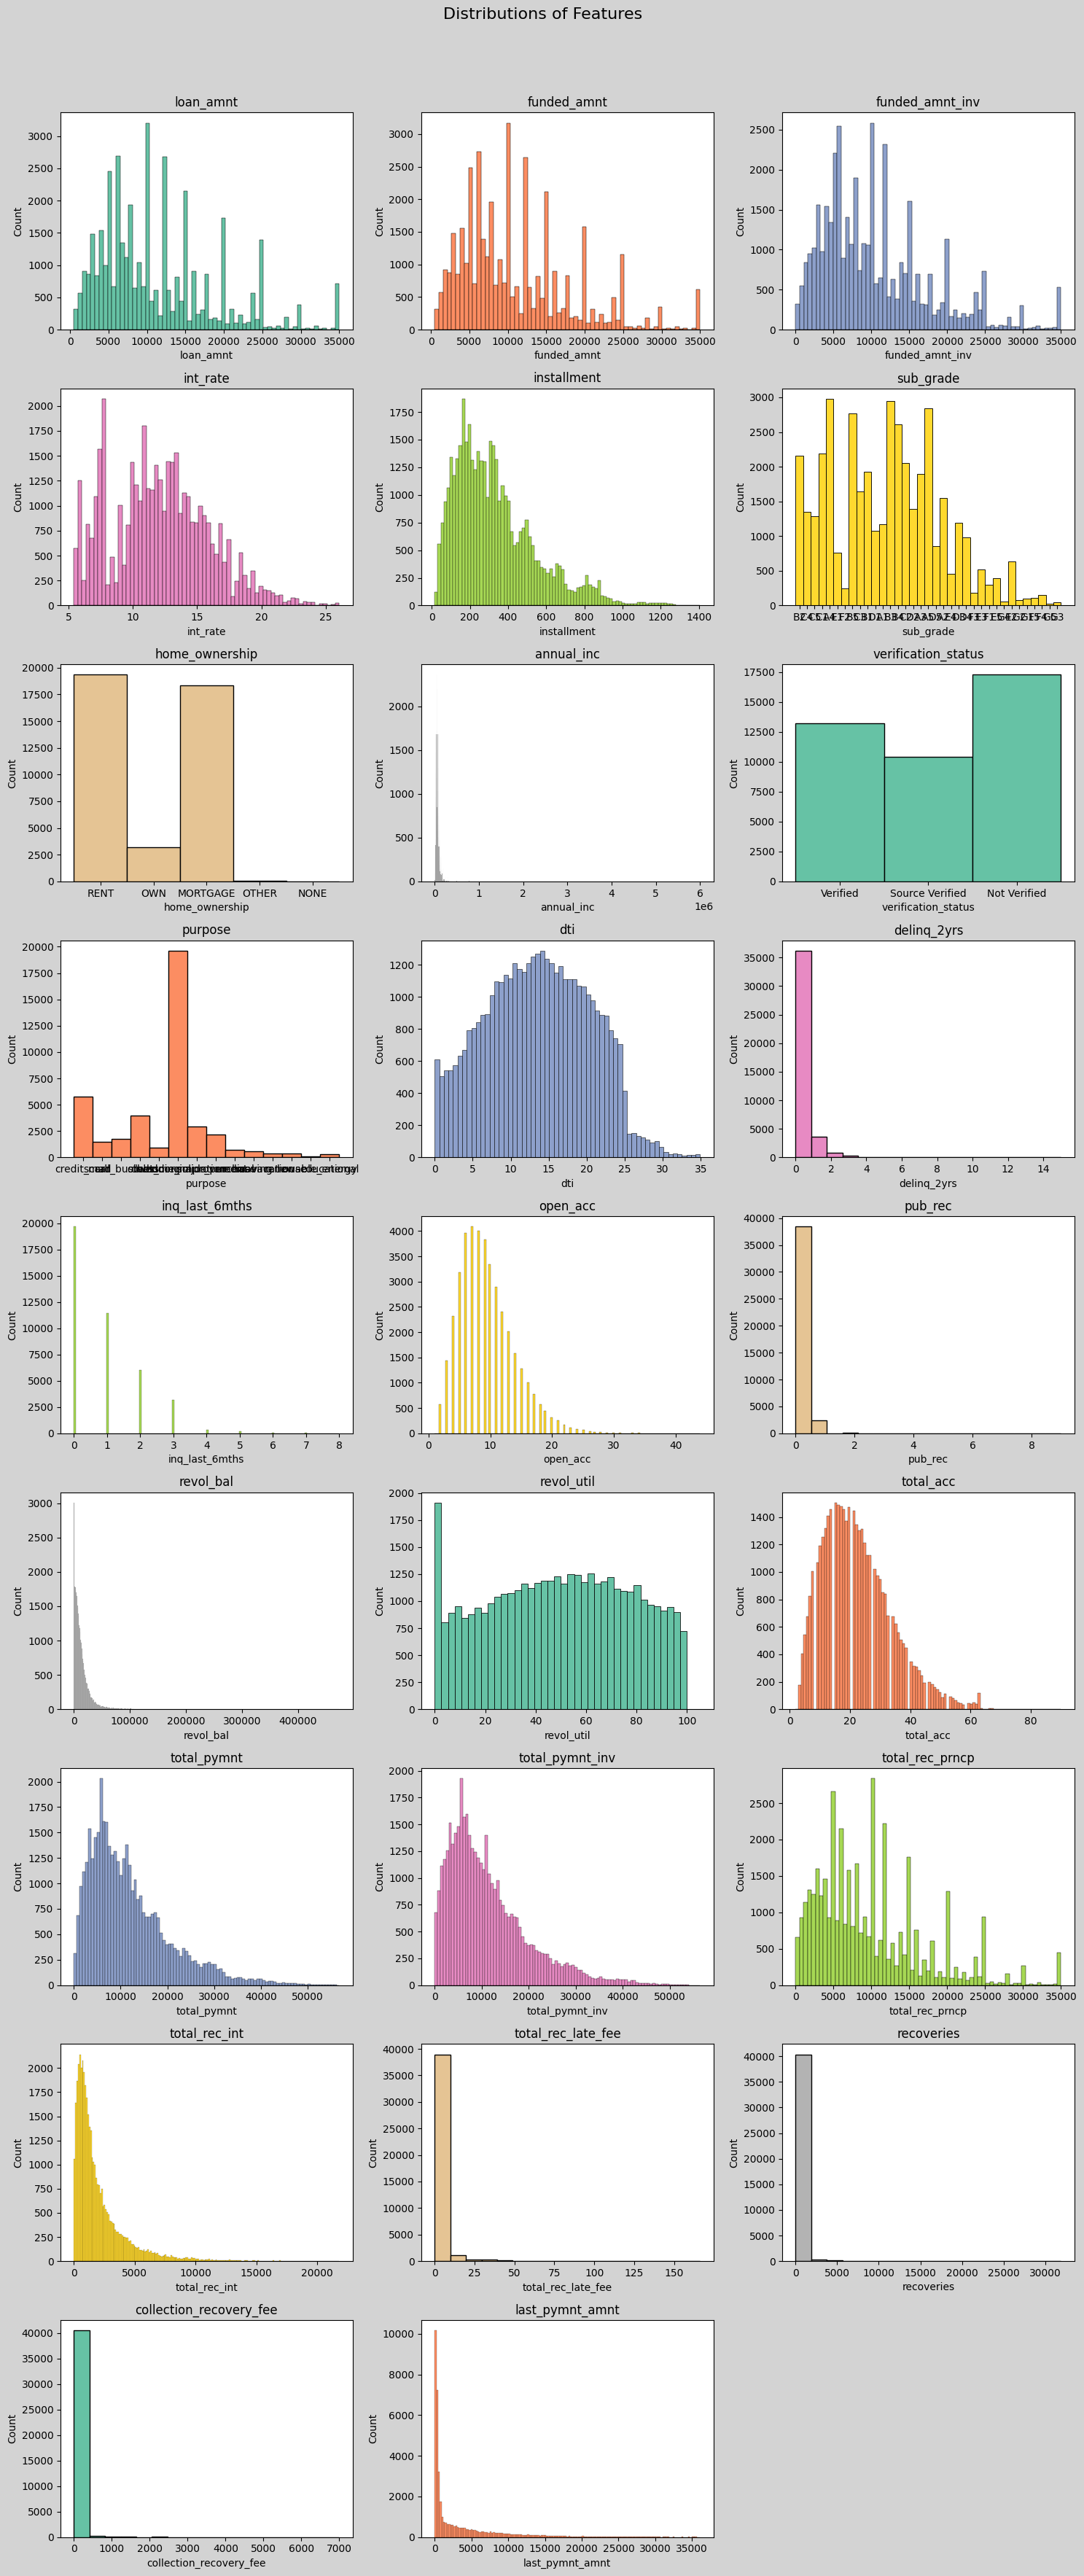

In [43]:
features = [col for col in df.columns if df[col].nunique() > 2]



rows = (len(features) + 2) // 3

cols = 3



# Set up the figure and axis for subplots

fig, axes = plt.subplots(rows, cols, figsize=(cols * 5, rows * 4))

axes = axes.flatten()  # Flatten in case of multiple rows



fig.patch.set_facecolor('lightgray')  # Set the background color of the entire figure



palette = sns.color_palette('Set2', len(features))



plotted_df = df.copy()

plotted_df['diff_loan_funded'] = plotted_df['loan_amnt'] - plotted_df['funded_amnt']

for i, col in enumerate(features):

    sns.histplot(x=plotted_df[col], kde=False, ax=axes[i], color=palette[i], alpha=1)  # Set alpha slightly transparent for better visualization

    axes[i].set_title(col)



# Remove any empty subplots (in case the number of features doesn't fill the grid)

for j in range(i + 1, len(axes)):

    fig.delaxes(axes[j])



fig.suptitle("Distributions of Features", fontsize=16)

plt.tight_layout(rect=[0, 0, 1, 0.96])  # Leave space for the main title



plt.show()

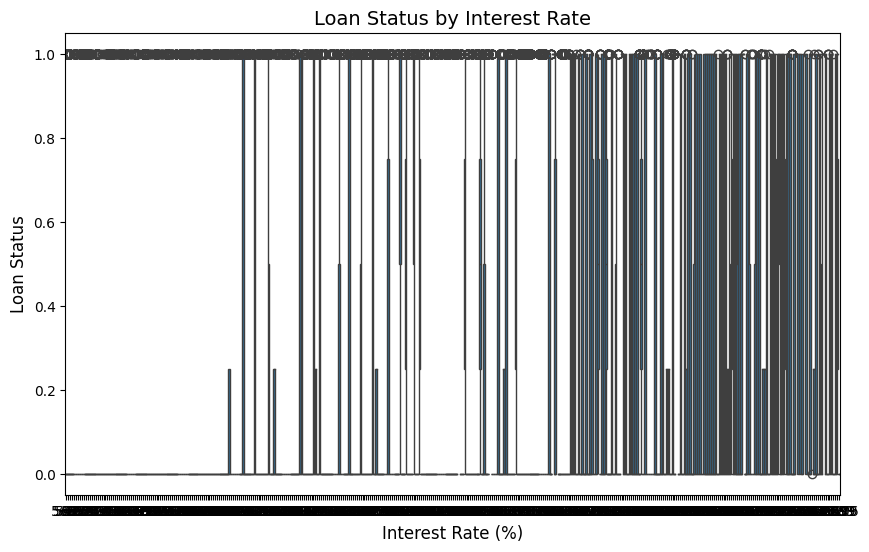

In [44]:
plt.figure(figsize=(10, 6))

sns.boxplot(x='int_rate', y='loan_status', data=df)



plt.title('Loan Status by Interest Rate', fontsize=14)

plt.xlabel('Interest Rate (%)', fontsize=12)

plt.ylabel('Loan Status', fontsize=12)



plt.show()

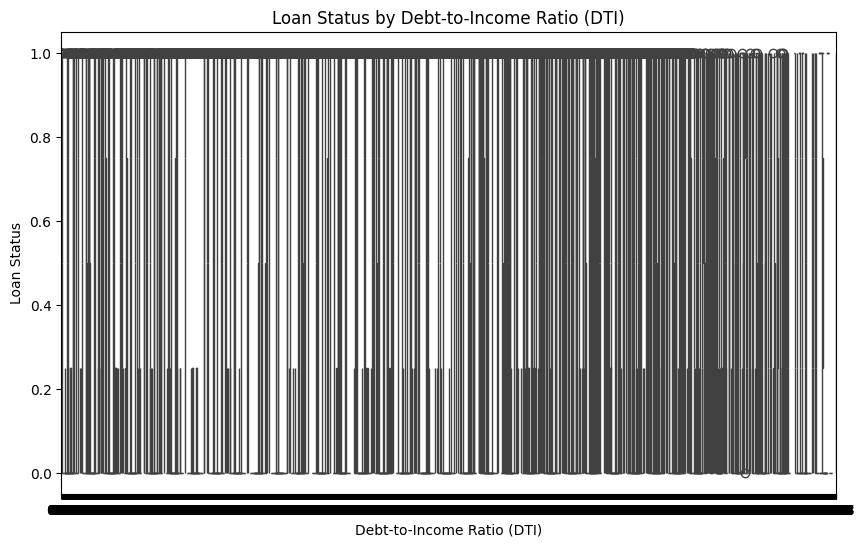

In [45]:
plt.figure(figsize=(10, 6))



sns.boxplot(x='dti', y='loan_status', data=df, color='#8A3C9D')



plt.title('Loan Status by Debt-to-Income Ratio (DTI)')

plt.xlabel('Debt-to-Income Ratio (DTI)')

plt.ylabel('Loan Status')



plt.show()

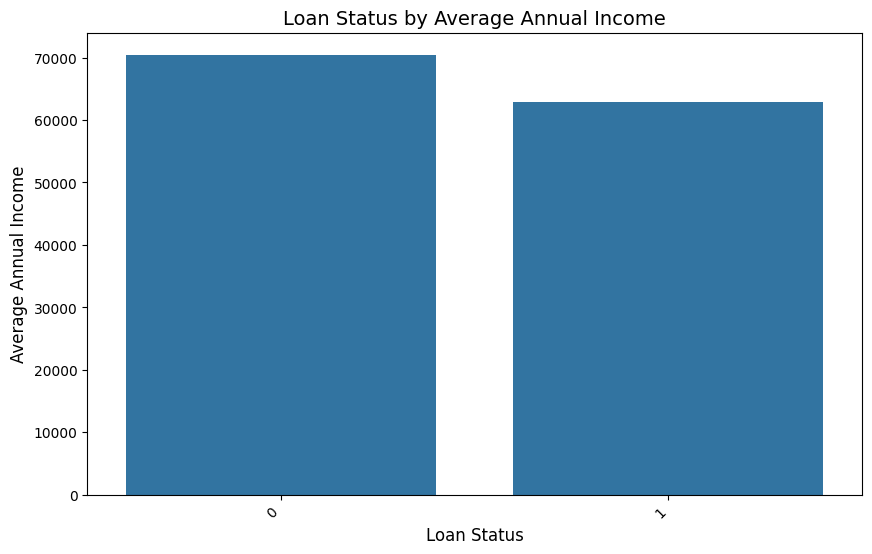

In [46]:
avg_income = df.groupby('loan_status')['annual_inc'].mean().reset_index()



plt.figure(figsize=(10, 6))

sns.barplot(y='annual_inc',x='loan_status', data=avg_income)



plt.title('Loan Status by Average Annual Income', fontsize=14)

plt.xlabel('Loan Status', fontsize=12)

plt.ylabel('Average Annual Income', fontsize=12)

plt.xticks(rotation=45, ha='right')



plt.show()

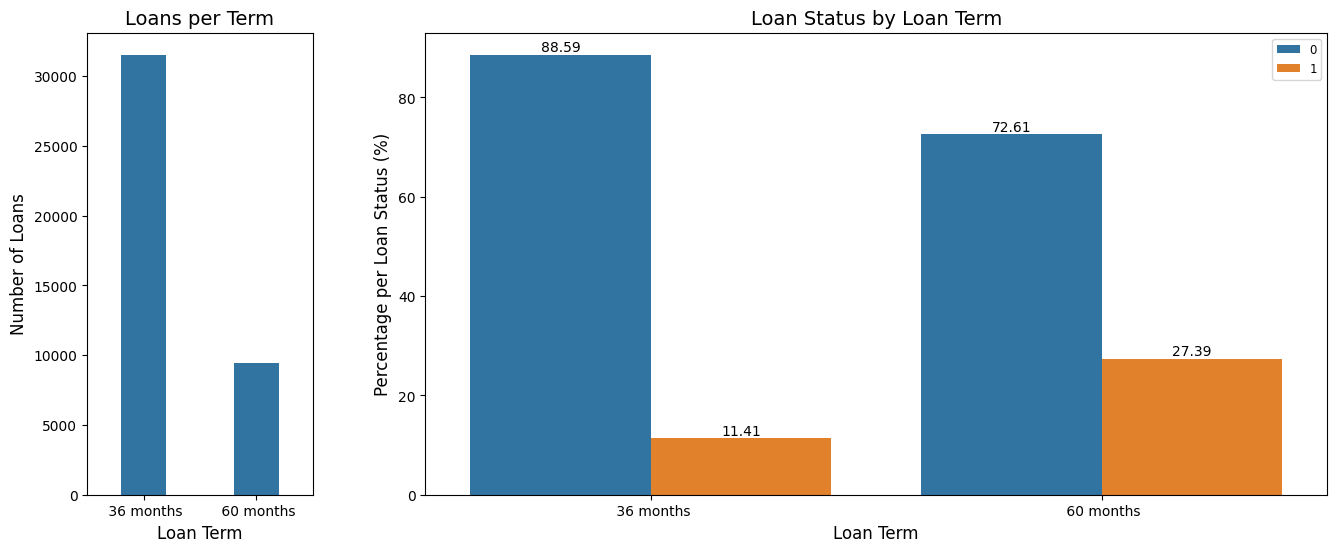

In [47]:
loans_per_term = df['term'].value_counts().reset_index()



count_data = df.groupby(['term', 'loan_status']).size().reset_index(name='count')

count_data['percentage'] = count_data['count'] / count_data.groupby('term')['count'].transform('sum') * 100



fig = plt.figure(figsize=(16, 6))

gs = gridspec.GridSpec(1, 2, width_ratios=[1, 4])



ax1 = plt.subplot(gs[0])

sns.barplot(x='term', y='count', data=loans_per_term, ax=ax1, width=0.4)

ax1.set_title('Loans per Term', fontsize=14)

ax1.set_xlabel('Loan Term', fontsize=12)

ax1.set_ylabel('Number of Loans', fontsize=12)



ax2 = plt.subplot(gs[1])

sns.barplot(x='term', y='percentage', hue='loan_status', data=count_data, ax=ax2, width=0.8)

for p in ax2.patches:

    height = p.get_height()

    if height > 0:

        ax2.text(

            p.get_x() + p.get_width() / 2.,

            height,

            f'{height:.2f}',

            ha='center',

            va='bottom'

        )

ax2.set_title('Loan Status by Loan Term', fontsize=14)

ax2.set_xlabel('Loan Term', fontsize=12)

ax2.set_ylabel('Percentage per Loan Status (%)', fontsize=12)



ax2.legend( fontsize='small')



plt.show()

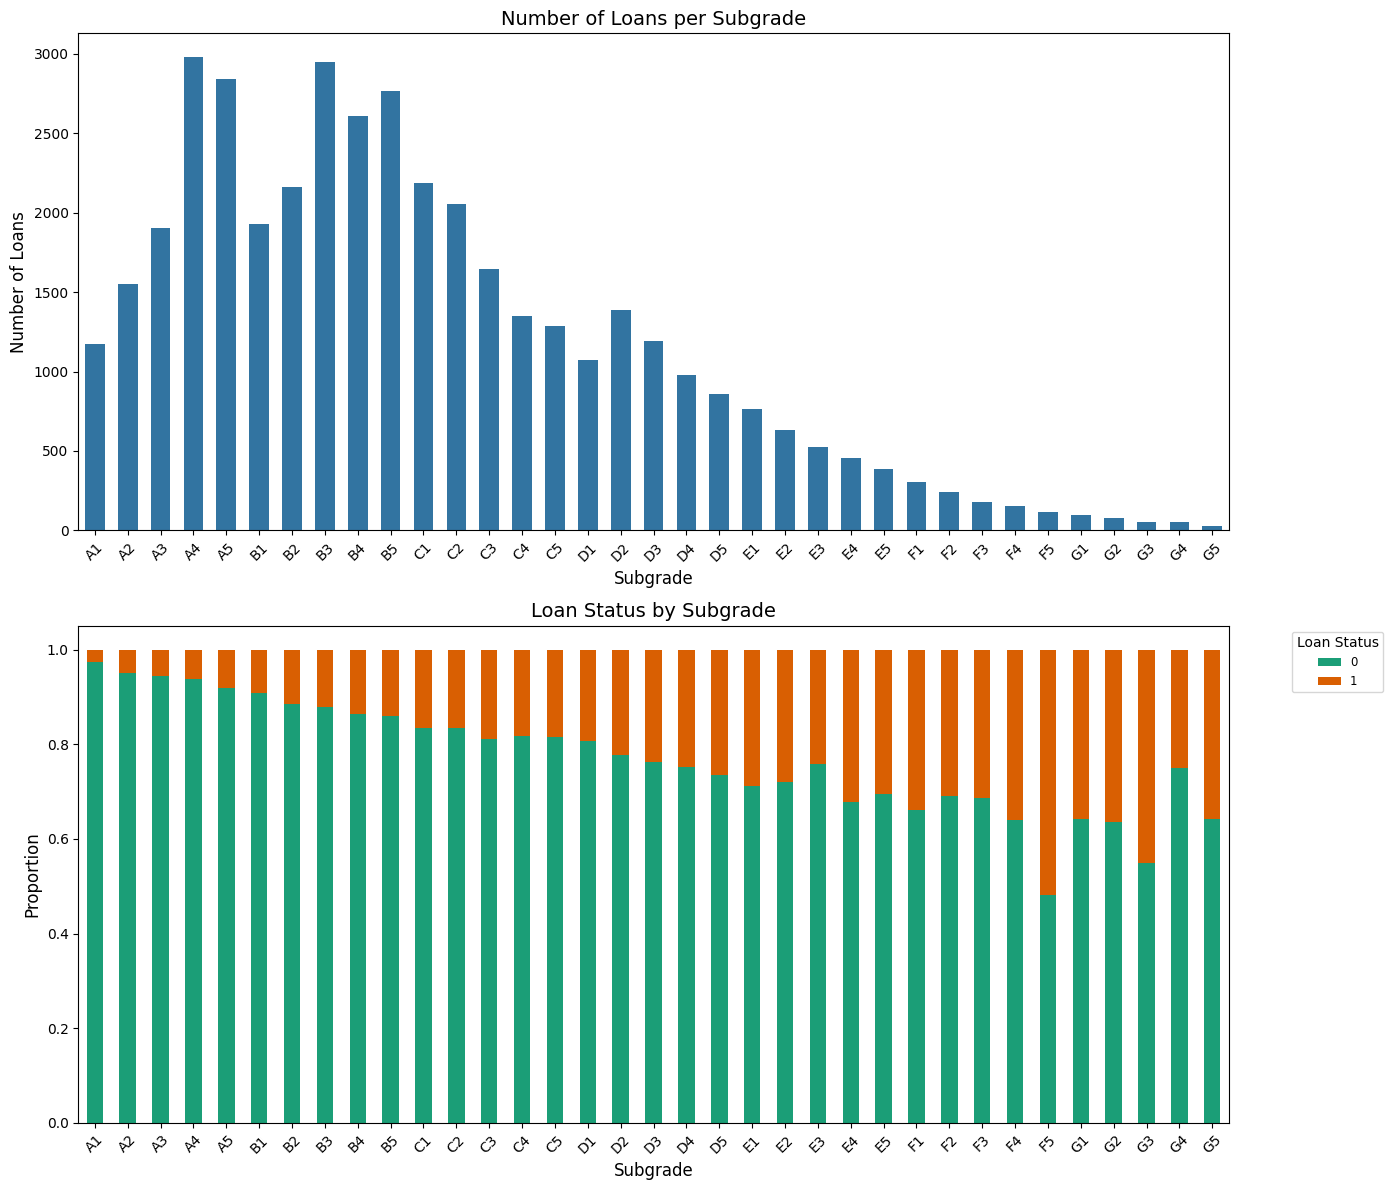

In [48]:
subgrade_counts = df['sub_grade'].value_counts().sort_index()



subgrade_proportions = df.groupby(['sub_grade', 'loan_status']).size().unstack(fill_value=0)

subgrade_proportions = subgrade_proportions.div(subgrade_proportions.sum(axis=1), axis=0)



fig, axes = plt.subplots(2, 1, figsize=(14, 12))

ax1, ax2 = axes[0], axes[1]



sns.barplot(x=subgrade_counts.index, y=subgrade_counts.values, ax=ax1, width=0.6)

ax1.set_title('Number of Loans per Subgrade', fontsize=14)

ax1.set_xlabel('Subgrade', fontsize=12)

ax1.set_ylabel('Number of Loans', fontsize=12)

ax1.tick_params(axis='x', rotation=45)



subgrade_proportions.plot(kind='bar', stacked=True, ax=ax2, color=sns.color_palette('Dark2'))

ax2.set_title('Loan Status by Subgrade', fontsize=14)

ax2.set_xlabel('Subgrade', fontsize=12)

ax2.set_ylabel('Proportion', fontsize=12)

ax2.tick_params(axis='x', rotation=45)

ax2.legend(title='Loan Status', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')



plt.tight_layout()

plt.show()

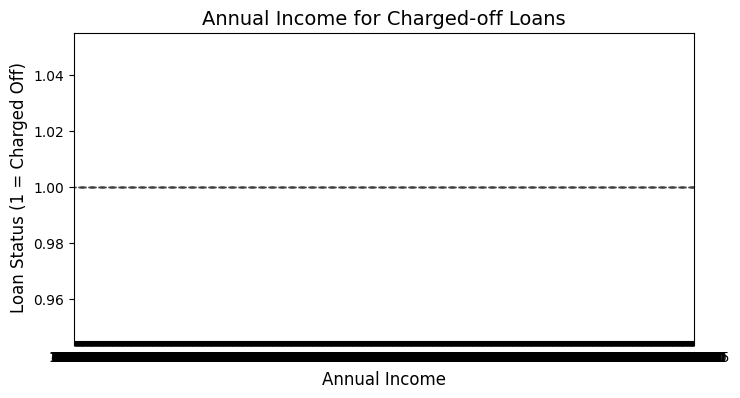

In [49]:
charges_off_df = df[df['loan_status'] == 1]

plt.figure(figsize=(8, 4))

sns.boxplot(x='annual_inc', y='loan_status', data=charges_off_df)

plt.title('Annual Income for Charged-off Loans', fontsize=14)
plt.ylabel('Loan Status (1 = Charged Off)', fontsize=12)
plt.xlabel('Annual Income', fontsize=12)

plt.show()

<Figure size 800x1000 with 0 Axes>

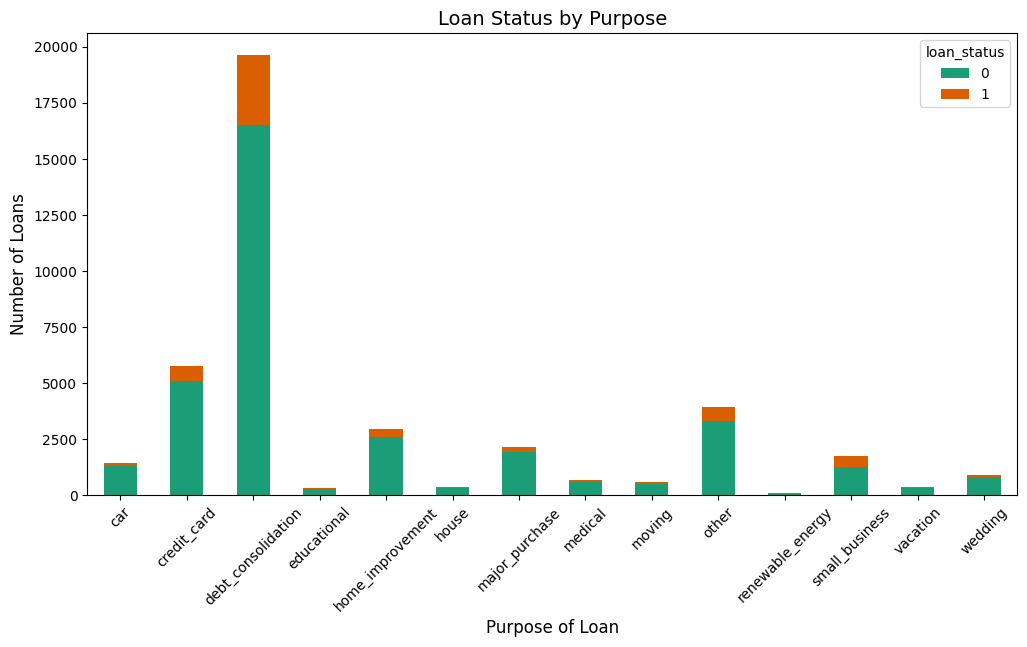

In [50]:
purpose_status_counts = df.groupby(['purpose', 'loan_status']).size().unstack(fill_value=0)



plt.figure(figsize=(8, 10))

purpose_status_counts.plot(kind='bar', stacked=True, figsize=(12, 6), color=sns.color_palette('Dark2'))



plt.title('Loan Status by Purpose', fontsize=14)

plt.xlabel('Purpose of Loan', fontsize=12)

plt.ylabel('Number of Loans', fontsize=12)

plt.xticks(rotation=45)



plt.show()


## Encoding

In [51]:
# Separate features and target
X = df.drop('loan_status', axis=1)

# Get categorical + numerical features
categorical_features = X.select_dtypes(include='object')
numerical_features = X.select_dtypes(exclude='object')

In [52]:
categorical_features.head()

,term,sub_grade,home_ownership,verification_status,purpose,initial_list_status
0,36 months,B2,RENT,Verified,credit_card,f
1,60 months,C4,RENT,Source Verified,car,f
2,36 months,C5,RENT,Not Verified,small_business,f
3,36 months,C1,RENT,Source Verified,other,f
5,36 months,A4,RENT,Source Verified,wedding,f


In [53]:
for i in categorical_features.columns:

  print({i: categorical_features[i].value_counts()})

{'term': term
36 months    31537
60 months     9406
Name: count, dtype: int64}
{'sub_grade': sub_grade
A4    2979
B3    2948
A5    2839
B5    2765
B4    2610
C1    2188
B2    2158
C2    2055
B1    1928
A3    1900
C3    1647
A2    1552
D2    1387
C4    1350
C5    1284
D3    1193
A1    1172
D1    1075
D4     979
D5     861
E1     765
E2     633
E3     525
E4     456
E5     389
F1     304
F2     242
F3     182
F4     153
F5     114
G1      98
G2      77
G4      56
G3      51
G5      28
Name: count, dtype: int64}
{'home_ownership': home_ownership
RENT        19339
MORTGAGE    18324
OWN          3183
OTHER          96
NONE            1
Name: count, dtype: int64}
{'verification_status': verification_status
Not Verified       17277
Verified           13236
Source Verified    10430
Name: count, dtype: int64}
{'purpose': purpose
debt_consolidation    19626
credit_card            5775
other                  3937
home_improvement       2938
major_purchase         2139
small_business         1722


In [54]:
def sub_grades_encoding(x):

  val = 0

  if 'A' in x:

    val = 7

  elif 'B' in x:

    val = 6

  elif 'C' in x:

    val = 5

  elif 'D' in x:

    val = 4

  elif 'E' in x:

    val = 3

  elif 'F' in x:

    val = 2

  elif 'G' in x:

    val = 1



  if '1' in x:

    val += 0.8

  elif '2' in x:

    val += 0.6

  elif '3' in x:

    val += 0.4

  elif '4' in x:

    val += 0.2

  elif '5' in x:

    val += 0.0



  return val



def verification_status(x):

  if x == 'Not Verified':

    return 0

  return 1

In [55]:
df['sub_grade'] = df['sub_grade'].apply(sub_grades_encoding)

In [56]:
df['sub_grade'].unique()

array([6.6, 5.2, 5. , 5.8, 7.2, 3.8, 2.6, 6. , 5.4, 6.8, 4.8, 7.8, 6.4,
       6.2, 5.6, 4.6, 7.4, 7. , 4. , 7.6, 3.2, 4.4, 4.2, 2.4, 3.4, 2.8,
       3. , 1.2, 3.6, 1.6, 1.8, 2. , 2.2, 1. , 1.4])

In [57]:
from sklearn.preprocessing import LabelEncoder



label_encoder = LabelEncoder()



df['term'] = label_encoder.fit_transform(df['term'])

df['initial_list_status'] = label_encoder.fit_transform(df['initial_list_status'])

In [58]:
df['verification_status'] = df['verification_status'].apply(verification_status)

In [59]:
X = df.drop('loan_status', axis=1)

categorical_features = X.select_dtypes(include='object')
numerical_features = X.select_dtypes(exclude='object')

In [60]:
categorical_features.isna().sum()

home_ownership    0
purpose           0
dtype: int64

In [61]:
encoded_features = pd.get_dummies(categorical_features, dtype=int)

encoded_features.head(3)

,home_ownership_MORTGAGE,home_ownership_NONE,home_ownership_OTHER,home_ownership_OWN,home_ownership_RENT,purpose_car,purpose_credit_card,purpose_debt_consolidation,purpose_educational,purpose_home_improvement,purpose_house,purpose_major_purchase,purpose_medical,purpose_moving,purpose_other,purpose_renewable_energy,purpose_small_business,purpose_vacation,purpose_wedding
0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0


In [62]:
df = pd.concat([df, encoded_features], axis=1)

In [63]:
df.drop(columns=categorical_features.columns, inplace=True)

In [64]:
df.head(3)

,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,sub_grade,annual_inc,verification_status,loan_status,dti,delinq_2yrs,inq_last_6mths,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_amnt,collections_12_mths_ex_med,home_ownership_MORTGAGE,home_ownership_NONE,home_ownership_OTHER,home_ownership_OWN,home_ownership_RENT,purpose_car,purpose_credit_card,purpose_debt_consolidation,purpose_educational,purpose_home_improvement,purpose_house,purpose_major_purchase,purpose_medical,purpose_moving,purpose_other,purpose_renewable_energy,purpose_small_business,purpose_vacation,purpose_wedding
0,5000.0,5000.0,4975.0,0,10.65,162.87,6.6,24000.0,1,0,27.65,0.0,1.0,3.0,0.0,13648.0,83.7,9.0,0,0.0,0.0,5861.071414,5831.78,5000.00,861.07,0.0,0.00,0.00,171.62,0.0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0
1,2500.0,2500.0,2500.0,1,15.27,59.83,5.2,30000.0,1,1,1.00,0.0,5.0,3.0,0.0,1687.0,9.4,4.0,0,0.0,0.0,1008.710000,1008.71,456.46,435.17,0.0,117.08,1.11,119.66,0.0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0
2,2400.0,2400.0,2400.0,0,15.96,84.33,5.0,12252.0,0,0,8.72,0.0,2.0,2.0,0.0,2956.0,98.5,10.0,0,0.0,0.0,3003.653644,3003.65,2400.00,603.65,0.0,0.00,0.00,649.91,0.0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0


In [65]:
df['loan_status'] = label_encoder.fit_transform(df['loan_status'])

## Handling Missing Values

In [66]:
df.isna().sum()

loan_amnt                     0
funded_amnt                   0
funded_amnt_inv               0
term                          0
int_rate                      0
installment                   0
sub_grade                     0
annual_inc                    0
verification_status           0
loan_status                   0
dti                           0
delinq_2yrs                   0
inq_last_6mths                0
open_acc                      0
pub_rec                       0
revol_bal                     0
revol_util                    0
total_acc                     0
initial_list_status           0
out_prncp                     0
out_prncp_inv                 0
total_pymnt                   0
total_pymnt_inv               0
total_rec_prncp               0
total_rec_int                 0
total_rec_late_fee            0
recoveries                    0
collection_recovery_fee       0
last_pymnt_amnt               0
collections_12_mths_ex_med    0
home_ownership_MORTGAGE       0
home_own

In [67]:
# # Importing necessary libraries

# from sklearn.experimental import enable_iterative_imputer  # To enable IterativeImputer

# from sklearn.impute import IterativeImputer



# # Initialize the IterativeImputer with optimized settings

# imputer = IterativeImputer(max_iter=5, random_state=0)



# # Fit and transform the data

# imputed_data = imputer.fit_transform(df)



# # Convert back to a DataFrame if needed

# imputed_df = pd.DataFrame(imputed_data, columns=df.columns)

'the IterativeImputer_credit.csv holds the imputed data'

In [68]:
imputed_df = pd.read_csv('IterativeImputer_credit.csv')

In [69]:
imputed_df.isna().sum()

loan_amnt                     0
funded_amnt                   0
funded_amnt_inv               0
term                          0
int_rate                      0
installment                   0
sub_grade                     0
annual_inc                    0
verification_status           0
loan_status                   0
dti                           0
delinq_2yrs                   0
inq_last_6mths                0
open_acc                      0
pub_rec                       0
revol_bal                     0
revol_util                    0
total_acc                     0
initial_list_status           0
out_prncp                     0
out_prncp_inv                 0
total_pymnt                   0
total_pymnt_inv               0
total_rec_prncp               0
total_rec_int                 0
total_rec_late_fee            0
recoveries                    0
collection_recovery_fee       0
last_pymnt_amnt               0
collections_12_mths_ex_med    0
tot_coll_amt                  0
tot_cur_

In [70]:
imputed_df.shape

(886253, 53)

In [71]:
imputed_df['inq_last_6mths'].value_counts()

inq_last_6mths
0.0     497247
1.0     241225
2.0      94020
3.0      37365
4.0      10737
5.0       3982
6.0       1227
7.0        194
8.0        121
9.0         47
10.0        23
11.0        15
12.0        14
15.0         8
14.0         5
13.0         4
16.0         3
18.0         3
24.0         2
17.0         2
19.0         2
33.0         1
32.0         1
31.0         1
28.0         1
25.0         1
27.0         1
20.0         1
Name: count, dtype: int64

# Split Data & Scaling

In [72]:
from sklearn.model_selection import train_test_split



x = imputed_df.drop(columns=['loan_status'])

y = imputed_df['loan_status']

In [73]:
x_rest, X, y_rest, Y = train_test_split(x, y, test_size=0.1, random_state=42, stratify=y, shuffle=True)

In [74]:
X.shape, Y.shape

((88626, 52), (88626,))

In [75]:
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.3, random_state=42, stratify=Y, shuffle=True)

In [76]:
from sklearn.preprocessing import MinMaxScaler



scaler = MinMaxScaler()

x_train = scaler.fit_transform(x_train)

x_test = scaler.transform(x_test)

In [77]:
x_train = pd.DataFrame(x_train, columns=x.columns)

x_test = pd.DataFrame(x_test, columns=x.columns)

# Feature Reduction

In [78]:
from sklearn.decomposition import PCA



pca = PCA(n_components=20)



pca.fit(x_train)

,n_components,20
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,None


In [79]:
cumulative_variance_ratio = np.cumsum(pca.explained_variance_ratio_)

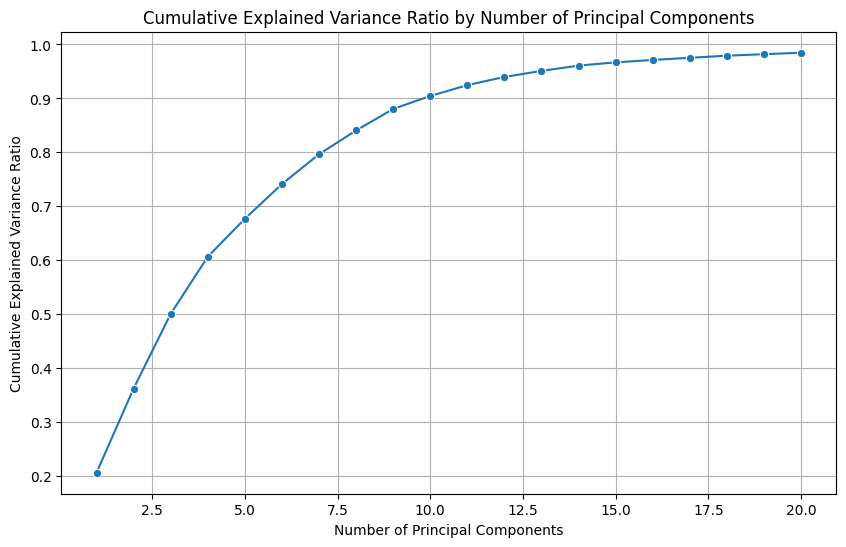

In [80]:
# Create a DataFrame for cumulative explained variance ratio
cvr = pd.DataFrame({
    'Number of Principal Components': range(1, len(cumulative_variance_ratio) + 1),
    'Cumulative Explained Variance Ratio': cumulative_variance_ratio
})

# Set up the figure
plt.figure(figsize=(10, 6))

# Create the line plot using Seaborn
sns.lineplot(data=cvr, 
             x='Number of Principal Components', 
             y='Cumulative Explained Variance Ratio', 
             marker='o')  # Adding markers for clarity

# Add title and labels
plt.title('Cumulative Explained Variance Ratio by Number of Principal Components')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance Ratio')

# Add grid lines for better readability
plt.grid(True)

# Show the figure
plt.show()

In [81]:
pca = PCA(n_components=25)

x_train_pca = pca.fit_transform(x_train)

x_test_pca = pca.transform(x_test)

# Modeling

## RandomForest

In [82]:
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report



rf_classifier = RandomForestClassifier(n_estimators=500,  max_depth=7, random_state=42)

rf_classifier.fit(x_train_pca, y_train)

,n_estimators,500
,criterion,'gini'
,max_depth,7
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [83]:
y_pred_train = rf_classifier.predict(x_train_pca)

In [84]:
cm = confusion_matrix(y_train, y_pred_train)

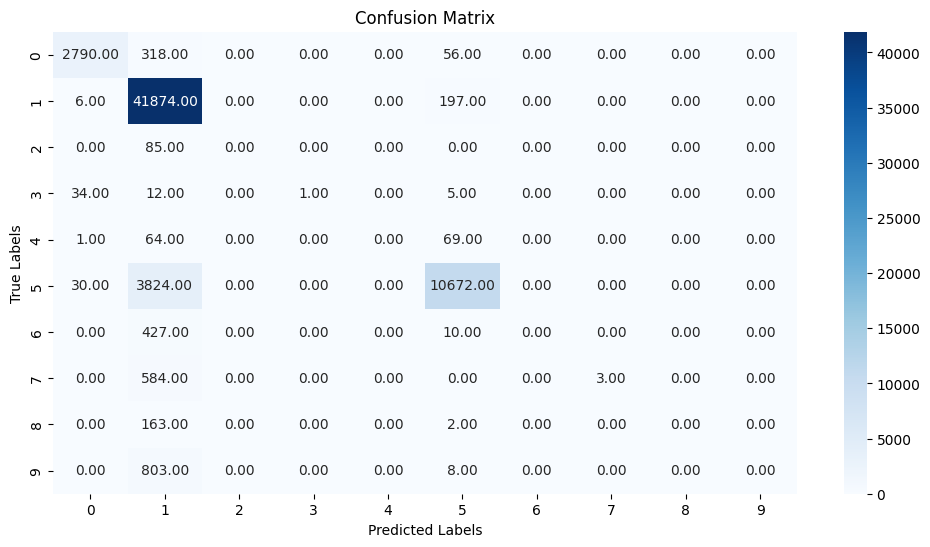

In [85]:
# Create a heatmap using Seaborn

plt.figure(figsize=(12, 6))  # Set the figure size

sns.heatmap(cm, annot=True, fmt='0.2f', cmap='Blues', cbar=True)



# Add titles and labels

plt.title('Confusion Matrix')

plt.xlabel('Predicted Labels')

plt.ylabel('True Labels')

plt.show()

In [86]:
print(classification_report(y_train, y_pred_train))

              precision    recall  f1-score   support

         0.0       0.98      0.88      0.93      3164
         1.0       0.87      1.00      0.93     42077
         2.0       0.00      0.00      0.00        85
         3.0       1.00      0.02      0.04        52
         4.0       0.00      0.00      0.00       134
         5.0       0.97      0.73      0.84     14526
         6.0       0.00      0.00      0.00       437
         7.0       1.00      0.01      0.01       587
         8.0       0.00      0.00      0.00       165
         9.0       0.00      0.00      0.00       811

    accuracy                           0.89     62038
   macro avg       0.48      0.26      0.27     62038
weighted avg       0.88      0.89      0.87     62038



In [87]:
f1_score(y_train, y_pred_train, average='weighted')

0.8725165775428758

In [88]:
y_pred_test = rf_classifier.predict(x_test_pca)

In [89]:
cm = confusion_matrix(y_test, y_pred_test)

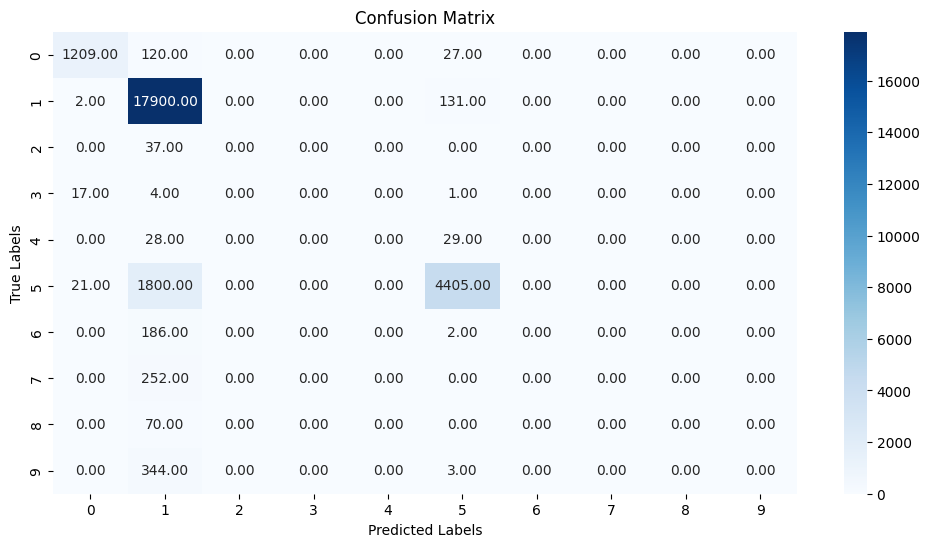

In [90]:
# Create a heatmap using Seaborn

plt.figure(figsize=(12, 6))  # Set the figure size

sns.heatmap(cm, annot=True, fmt='0.2f', cmap='Blues', cbar=True)



# Add titles and labels

plt.title('Confusion Matrix')

plt.xlabel('Predicted Labels')

plt.ylabel('True Labels')

plt.show()

In [91]:
print(classification_report(y_test, y_pred_test))

              precision    recall  f1-score   support

         0.0       0.97      0.89      0.93      1356
         1.0       0.86      0.99      0.92     18033
         2.0       0.00      0.00      0.00        37
         3.0       0.00      0.00      0.00        22
         4.0       0.00      0.00      0.00        57
         5.0       0.96      0.71      0.81      6226
         6.0       0.00      0.00      0.00       188
         7.0       0.00      0.00      0.00       252
         8.0       0.00      0.00      0.00        70
         9.0       0.00      0.00      0.00       347

    accuracy                           0.88     26588
   macro avg       0.28      0.26      0.27     26588
weighted avg       0.86      0.88      0.86     26588



In [92]:
f1_score(y_test, y_pred_test, average='weighted')

0.8641512391169216

## XGBoost

In [93]:
from xgboost import XGBClassifier
model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='binary:logistic',
    eval_metric='logloss',
    use_label_encoder=False,
    n_jobs=-1
)

In [94]:
model.fit(x_train_pca, y_train)

,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


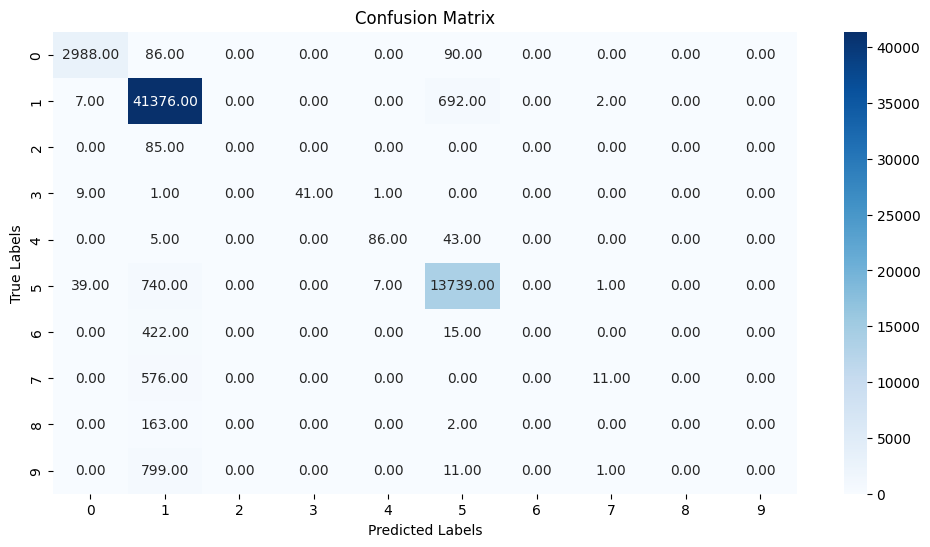

              precision    recall  f1-score   support

         0.0       0.98      0.94      0.96      3164
         1.0       0.93      0.98      0.96     42077
         2.0       0.00      0.00      0.00        85
         3.0       1.00      0.79      0.88        52
         4.0       0.91      0.64      0.75       134
         5.0       0.94      0.95      0.94     14526
         6.0       0.00      0.00      0.00       437
         7.0       0.73      0.02      0.04       587
         8.0       0.00      0.00      0.00       165
         9.0       0.00      0.00      0.00       811

    accuracy                           0.94     62038
   macro avg       0.55      0.43      0.45     62038
weighted avg       0.91      0.94      0.92     62038



0.9229115850297535

In [95]:
y_pred_train_xgb = model.predict(x_train_pca)

cm = confusion_matrix(y_train, y_pred_train_xgb)

# Create a heatmap using Seaborn

plt.figure(figsize=(12, 6))  # Set the figure size

sns.heatmap(cm, annot=True, fmt='0.2f', cmap='Blues', cbar=True)



# Add titles and labels

plt.title('Confusion Matrix')

plt.xlabel('Predicted Labels')

plt.ylabel('True Labels')

plt.show()

print(classification_report(y_train, y_pred_train_xgb))

f1_score(y_train, y_pred_train_xgb, average='weighted')

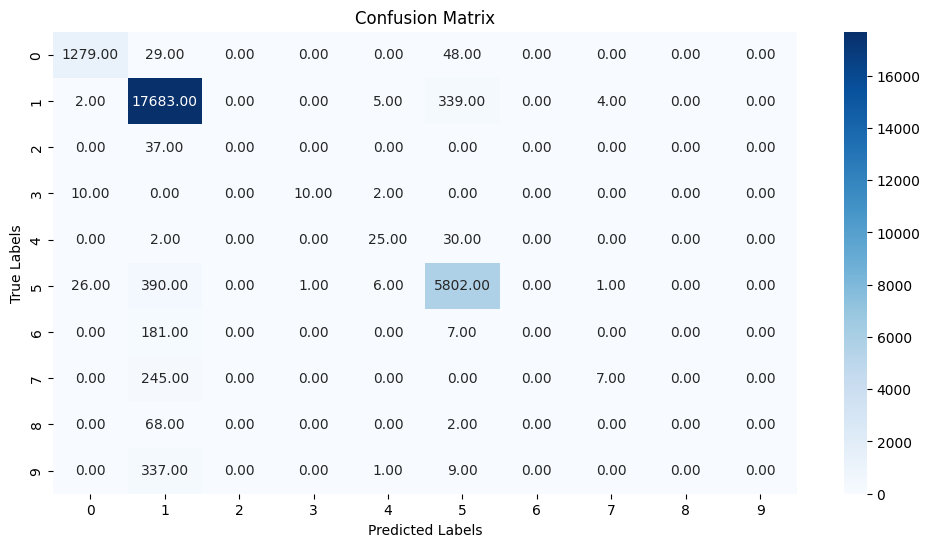

              precision    recall  f1-score   support

         0.0       0.97      0.94      0.96      1356
         1.0       0.93      0.98      0.96     18033
         2.0       0.00      0.00      0.00        37
         3.0       0.91      0.45      0.61        22
         4.0       0.64      0.44      0.52        57
         5.0       0.93      0.93      0.93      6226
         6.0       0.00      0.00      0.00       188
         7.0       0.58      0.03      0.05       252
         8.0       0.00      0.00      0.00        70
         9.0       0.00      0.00      0.00       347

    accuracy                           0.93     26588
   macro avg       0.50      0.38      0.40     26588
weighted avg       0.91      0.93      0.92     26588



0.9171513230687234

In [96]:
y_pred_test_xgb = model.predict(x_test_pca)

cm = confusion_matrix(y_test, y_pred_test_xgb)

# Create a heatmap using Seaborn

plt.figure(figsize=(12, 6))  # Set the figure size

sns.heatmap(cm, annot=True, fmt='0.2f', cmap='Blues', cbar=True)



# Add titles and labels

plt.title('Confusion Matrix')

plt.xlabel('Predicted Labels')

plt.ylabel('True Labels')

plt.show()

print(classification_report(y_test, y_pred_test_xgb))

f1_score(y_test, y_pred_test_xgb, average='weighted')

In [97]:
label_encoder.classes_

array([0, 1])

## XGBoost on all data

In [98]:
x = imputed_df.drop(columns=['loan_status'])

y = imputed_df['loan_status']

In [99]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42, stratify=y, shuffle=True)

In [100]:
x_train = scaler.fit_transform(x_train)

x_test = scaler.transform(x_test)

In [101]:
x_train = pd.DataFrame(x_train, columns=x.columns)

x_test = pd.DataFrame(x_test, columns=x.columns)

In [102]:
pca = PCA(n_components=25)

x_train_pca = pca.fit_transform(x_train)

x_test_pca = pca.transform(x_test)

In [103]:
model.fit(x_train_pca, y_train)

,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


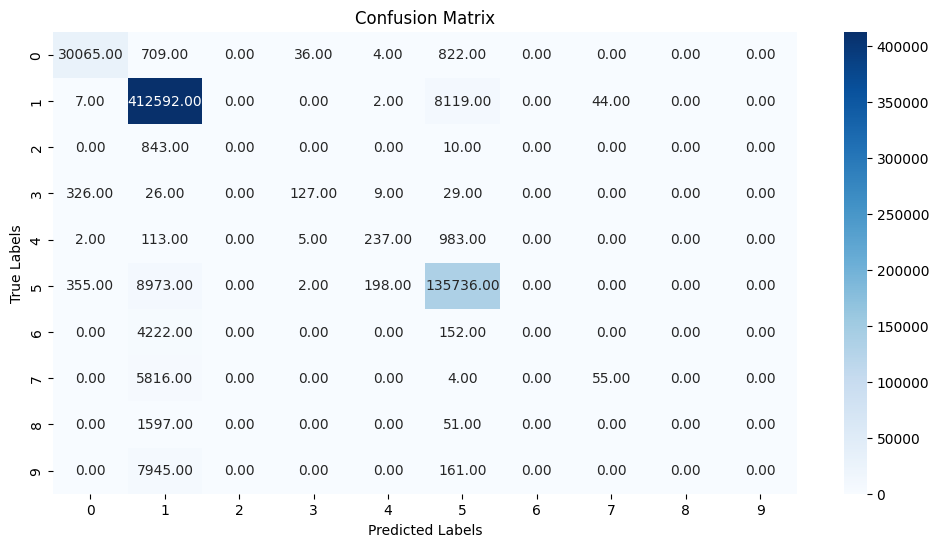

              precision    recall  f1-score   support

         0.0       0.98      0.95      0.96     31636
         1.0       0.93      0.98      0.96    420764
         2.0       0.00      0.00      0.00       853
         3.0       0.75      0.25      0.37       517
         4.0       0.53      0.18      0.26      1340
         5.0       0.93      0.93      0.93    145264
         6.0       0.00      0.00      0.00      4374
         7.0       0.56      0.01      0.02      5875
         8.0       0.00      0.00      0.00      1648
         9.0       0.00      0.00      0.00      8106

    accuracy                           0.93    620377
   macro avg       0.47      0.33      0.35    620377
weighted avg       0.91      0.93      0.92    620377

Accuracy Train: 0.9330004174880758
F1 Score Trian: 0.9164628735501048


In [104]:
y_pred_train_xgb = model.predict(x_train_pca)
cm = confusion_matrix(y_train, y_pred_train_xgb)
# Create a heatmap using Seaborn
plt.figure(figsize=(12, 6))  # Set the figure size
sns.heatmap(cm, annot=True, fmt='0.2f', cmap='Blues', cbar=True)

# Add titles and labels
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

print(classification_report(y_train, y_pred_train_xgb))

Accuracy_Train = accuracy_score(y_train, y_pred_train_xgb)
F1_Score_Train = f1_score(y_train, y_pred_train_xgb, average='weighted')

print(f"Accuracy Train: {Accuracy_Train}")
print(f"F1 Score Trian: {F1_Score_Train}")

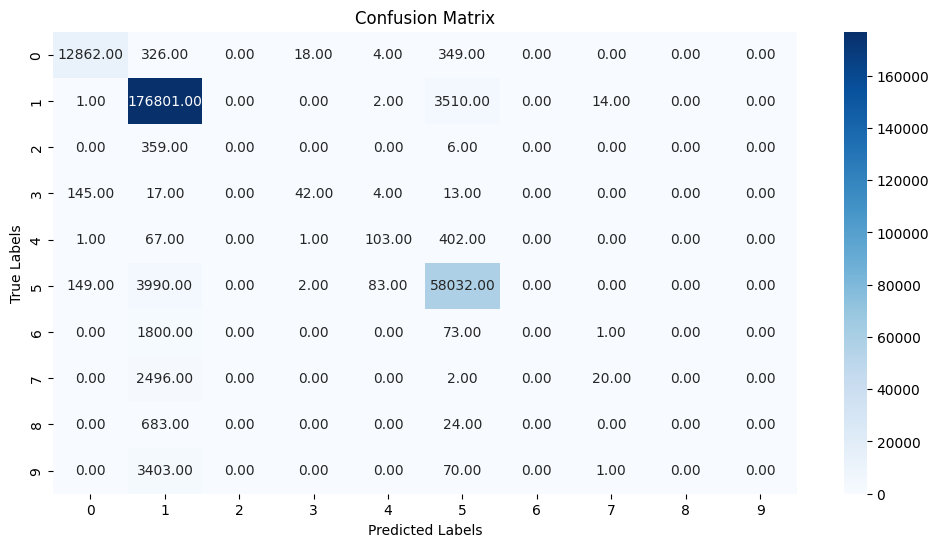

              precision    recall  f1-score   support

         0.0       0.98      0.95      0.96     13559
         1.0       0.93      0.98      0.95    180328
         2.0       0.00      0.00      0.00       365
         3.0       0.67      0.19      0.30       221
         4.0       0.53      0.18      0.27       574
         5.0       0.93      0.93      0.93     62256
         6.0       0.00      0.00      0.00      1874
         7.0       0.56      0.01      0.02      2518
         8.0       0.00      0.00      0.00       707
         9.0       0.00      0.00      0.00      3474

    accuracy                           0.93    265876
   macro avg       0.46      0.32      0.34    265876
weighted avg       0.91      0.93      0.92    265876

Accuracy Test: 0.9322390888985843
F1 Score Test: 0.9156566484528764


In [105]:
y_pred_test_xgb = model.predict(x_test_pca)
cm = confusion_matrix(y_test, y_pred_test_xgb)
# Create a heatmap using Seaborn
plt.figure(figsize=(12, 6))  # Set the figure size
sns.heatmap(cm, annot=True, fmt='0.2f', cmap='Blues', cbar=True)

# Add titles and labels
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

print(classification_report(y_test, y_pred_test_xgb))

Accuracy_Test = accuracy_score(y_test, y_pred_test_xgb)
F1_Score_Test = f1_score(y_test, y_pred_test_xgb, average='weighted')

print(f"Accuracy Test: {Accuracy_Test}")
print(f"F1 Score Test: {F1_Score_Test}")

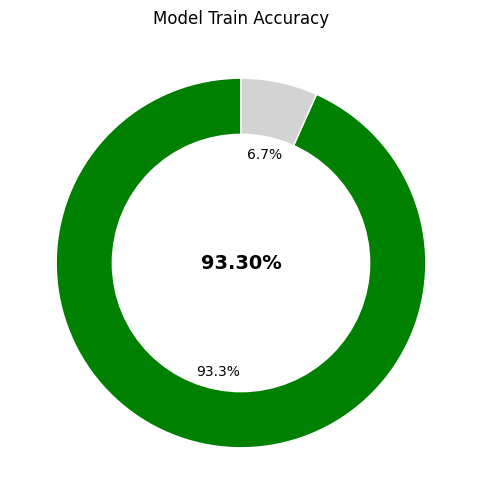

In [106]:
# Create a pie chart with a single slice representing the accuracy
plt.figure(figsize=(6, 6))  # Adjust size as needed
plt.pie([round(Accuracy_Train*100, 2), 100 - round(Accuracy_Train*100, 2)],
        colors=['green', 'lightgray'],
        startangle=90,
        autopct='%1.1f%%',
        wedgeprops={'edgecolor': 'white'})

# Add a circle in the center to create the donut effect
centre_circle = plt.Circle((0, 0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

# Add accuracy text in the center
plt.text(0, 0, f'{round(Accuracy_Train*100, 2):.2f}%', ha='center', va='center', fontsize=14, fontweight='bold')

# Add a title
plt.title('Model Train Accuracy')

# Show the plot
plt.show()

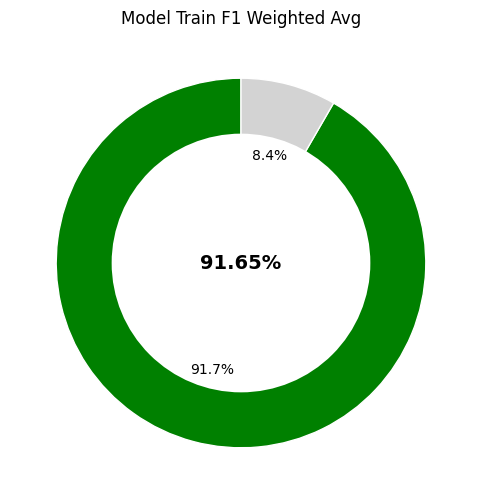

In [107]:
plt.figure(figsize=(6, 6))  # Adjust size as needed
plt.pie([round(F1_Score_Train*100, 2), 100 - round(F1_Score_Train*100, 2)],
        colors=['green', 'lightgray'],
        startangle=90,
        autopct='%1.1f%%',
        wedgeprops={'edgecolor': 'white'})

# Add a circle in the center to create the donut effect
centre_circle = plt.Circle((0, 0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

# Add accuracy text in the center
plt.text(0, 0, f'{round(F1_Score_Train*100, 2):.2f}%', ha='center', va='center', fontsize=14, fontweight='bold')

# Add a title
plt.title('Model Train F1 Weighted Avg')

# Show the plot
plt.show()

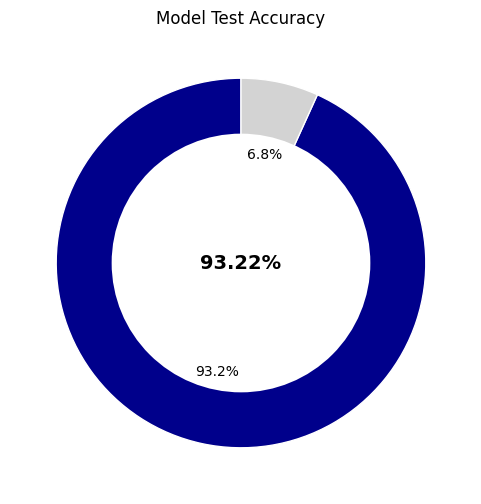

In [108]:
# Create a pie chart with a single slice representing the accuracy
plt.figure(figsize=(6, 6))  # Adjust size as needed
plt.pie([round(Accuracy_Test*100, 2), 100 - round(Accuracy_Test*100, 2)],
        colors=['darkblue', 'lightgray'],
        startangle=90,
        autopct='%1.1f%%',
        wedgeprops={'edgecolor': 'white'})

# Add a circle in the center to create the donut effect
centre_circle = plt.Circle((0, 0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

# Add accuracy text in the center
plt.text(0, 0, f'{round(Accuracy_Test*100, 2):.2f}%', ha='center', va='center', fontsize=14, fontweight='bold')

# Add a title
plt.title('Model Test Accuracy')

# Show the plot
plt.show()

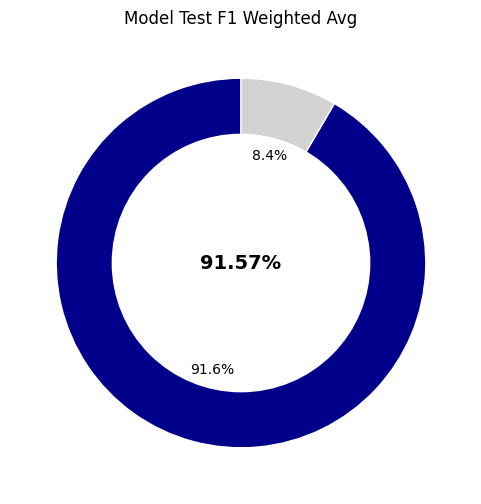

In [109]:
plt.figure(figsize=(6, 6))  # Adjust size as needed
plt.pie([round(F1_Score_Test*100, 2), 100 - round(F1_Score_Test*100, 2)],
        colors=['darkblue', 'lightgray'],
        startangle=90,
        autopct='%1.1f%%',
        wedgeprops={'edgecolor': 'white'})

# Add a circle in the center to create the donut effect
centre_circle = plt.Circle((0, 0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

# Add accuracy text in the center
plt.text(0, 0, f'{round(F1_Score_Test*100, 2):.2f}%', ha='center', va='center', fontsize=14, fontweight='bold')

# Add a title
plt.title('Model Test F1 Weighted Avg')

# Show the plot
plt.show()

In [110]:
# ================================
# 1. IMPORTS
# ================================
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from xgboost import XGBClassifier

from sklearn.metrics import classification_report, accuracy_score


# ================================
# 2. FEATURES & TARGET
# ================================
# 🔴 CHANGE 'target_column' to your actual target column name
X = df.drop('loan_status', axis=1)
y = df['loan_status']


# ================================
# 3. TRAIN-TEST SPLIT
# ================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# ================================
# 4. SCALING (important for LR)
# ================================
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# ================================
# 5. DEFINE MODELS
# ================================
log_model = LogisticRegression(class_weight='balanced', max_iter=1000)
rf_model = RandomForestClassifier(n_estimators=80, max_depth=4 ,random_state=42, class_weight='balanced')
xgb_model = XGBClassifier(n_estimators=120, max_depth = 3, learning_rate = 0.1, subsample = 0.7, colsample_bytree = 0.7, n_jobs = -1, use_label_encoder=False, eval_metric='logloss')


# ================================
# 6. HYBRID MODEL (ENSEMBLE)
# ================================
hybrid_model = VotingClassifier(
    estimators=[
        ('lr', log_model),
        ('rf', rf_model),
        ('xgb', xgb_model)
    ],
    voting='soft'   # needed for probabilities
)


# ================================
# 7. TRAIN
# ================================
hybrid_model.fit(X_train_scaled, y_train)


# ================================
# 8. PREDICT
# ================================
y_prob_hybrid = hybrid_model.predict_proba(X_test_scaled)[:, 1]
y_pred_hybrid = (y_prob_hybrid > 0.8).astype(int)

# ================================
# 9. EVALUATION
# ================================
print("Hybrid Model Accuracy:", accuracy_score(y_test, y_pred_hybrid))
print("\nClassification Report:\n", classification_report(y_test, y_pred_hybrid))


# ================================
# 10. RISK SCORING SYSTEM (NOVELTY)
# ================================
def risk_category(prob):
    if prob < 0.3:
        return "Low Risk"
    elif prob < 0.7:
        return "Medium Risk"
    else:
        return "High Risk"

risk_labels = [risk_category(p) for p in y_prob_hybrid]


# ================================
# 11. FINAL OUTPUT TABLE
# ================================
results_df = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted_Prob": y_prob_hybrid,
    "Risk_Category": risk_labels
})

print("\nSample Results:")
print(results_df.head())


# ================================
# 12. DISTRIBUTION (OPTIONAL)
# ================================
print("\nRisk Distribution:")
print(results_df["Risk_Category"].value_counts())

Hybrid Model Accuracy: 0.9874221516668702

Classification Report:
               precision    recall  f1-score   support

           0       0.99      1.00      0.99      6934
           1       1.00      0.92      0.96      1255

    accuracy                           0.99      8189
   macro avg       0.99      0.96      0.97      8189
weighted avg       0.99      0.99      0.99      8189


Sample Results:
   Actual  Predicted_Prob Risk_Category
0       0        0.042146      Low Risk
1       1        0.835820     High Risk
2       0        0.060215      Low Risk
3       0        0.035163      Low Risk
4       0        0.070273      Low Risk

Risk Distribution:
Risk_Category
Low Risk       6925
High Risk      1208
Medium Risk      56
Name: count, dtype: int64


In [111]:
# ================================
# BAGGING MODEL (Random Forest)
# ================================
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

bagging_model = RandomForestClassifier(
    n_estimators=80, max_depth=4 ,random_state=42, class_weight='balanced'
)

# Train
bagging_model.fit(X_train, y_train)

# Predict
y_pred_bag = bagging_model.predict(X_test)

# Evaluate
print("Bagging Accuracy:", accuracy_score(y_test, y_pred_bag))
print("\nClassification Report:\n", classification_report(y_test, y_pred_bag))

Bagging Accuracy: 0.9831481255342532

Classification Report:
               precision    recall  f1-score   support

           0       0.98      1.00      0.99      6934
           1       0.97      0.91      0.94      1255

    accuracy                           0.98      8189
   macro avg       0.98      0.96      0.97      8189
weighted avg       0.98      0.98      0.98      8189



In [112]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

boosting_model = XGBClassifier(
    n_estimators=60,          # ↓ fewer trees
    max_depth=2,              # ↓ simpler trees
    learning_rate=0.05,       # ↓ slower learning
    subsample=0.6,            # randomness
    colsample_bytree=0.6,     # randomness
    reg_alpha=1,              # L1 regularization
    reg_lambda=2,             # L2 regularization
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

# Train
boosting_model.fit(X_train, y_train)

# Predict
y_prob = boosting_model.predict_proba(X_test)[:, 1]

# Slightly strict threshold (your style)
y_pred = (y_prob > 0.7).astype(int)

# Evaluate
print("Boosting Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Boosting Accuracy: 0.9597020393210404

Classification Report:
               precision    recall  f1-score   support

           0       0.95      1.00      0.98      6934
           1       1.00      0.74      0.85      1255

    accuracy                           0.96      8189
   macro avg       0.98      0.87      0.91      8189
weighted avg       0.96      0.96      0.96      8189



In [113]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Base models (slightly weaker)
base_models = [
    ('rf', RandomForestClassifier(
        n_estimators=70,        # ↓ from 80
        max_depth=4,            # ↓ from 4
        random_state=42
    )),
    
    ('xgb', XGBClassifier(
        n_estimators=80,        # ↓ from 100
        max_depth=2,            # ↓ from 3
        learning_rate=0.08,     # ↓ from 0.1
        subsample=0.7,          # add randomness
        colsample_bytree=0.7,
        reg_lambda=1.5,         # regularization
        use_label_encoder=False,
        eval_metric='logloss'
    ))
]

# Meta model (slightly regularized)
meta_model = LogisticRegression(
    C=0.5,                     # ↓ from default (adds regularization)
    max_iter=1000
)

# Stacking
stacking_model = StackingClassifier(
    estimators=base_models,
    final_estimator=meta_model,
    passthrough=False
)

# Train
stacking_model.fit(X_train_scaled, y_train)

# Predict
y_prob = stacking_model.predict_proba(X_test_scaled)[:, 1]

# Slightly stricter threshold
y_pred_stack = (y_prob > 0.68).astype(int)

# Evaluate
print("Stacking Accuracy:", accuracy_score(y_test, y_pred_stack))
print("\nClassification Report:\n", classification_report(y_test, y_pred_stack))

Stacking Accuracy: 0.9903529124435217

Classification Report:
               precision    recall  f1-score   support

           0       0.99      1.00      0.99      6934
           1       1.00      0.94      0.97      1255

    accuracy                           0.99      8189
   macro avg       0.99      0.97      0.98      8189
weighted avg       0.99      0.99      0.99      8189



In [114]:
# ================================
# STORE ALL MODEL RESULTS
# ================================

results = []

# Hybrid (Voting)
results.append([
    "Voting (Hybrid)",
    accuracy_score(y_test, y_pred_hybrid)
])

# Bagging
results.append([
    "Random Forest (Bagging)",
    accuracy_score(y_test, y_pred_bag)
])

# Boosting
results.append([
    "XGBoost (Boosting)",
    accuracy_score(y_test, y_pred)
])

# Stacking
results.append([
    "Stacking",
    accuracy_score(y_test, y_pred_stack)
])

In [115]:
# ================================
# COMPARISON TABLE
# ================================

results_df_compare = pd.DataFrame(results, columns=["Model", "Accuracy"])

# Sort best → worst
results_df_compare = results_df_compare.sort_values(by="Accuracy", ascending=False)

print("📊 Model Comparison:")
display(results_df_compare)

📊 Model Comparison:


,Model,Accuracy
3,Stacking,0.990353
0,Voting (Hybrid),0.987422
1,Random Forest (Bagging),0.983148
2,XGBoost (Boosting),0.959702


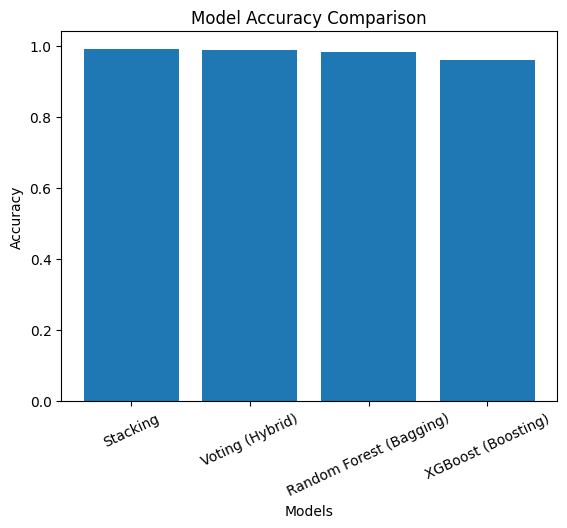

In [116]:
# ================================
# VISUAL COMPARISON
# ================================

import matplotlib.pyplot as plt

plt.figure()
plt.bar(results_df_compare["Model"], results_df_compare["Accuracy"])
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
plt.xticks(rotation=25)
plt.show()

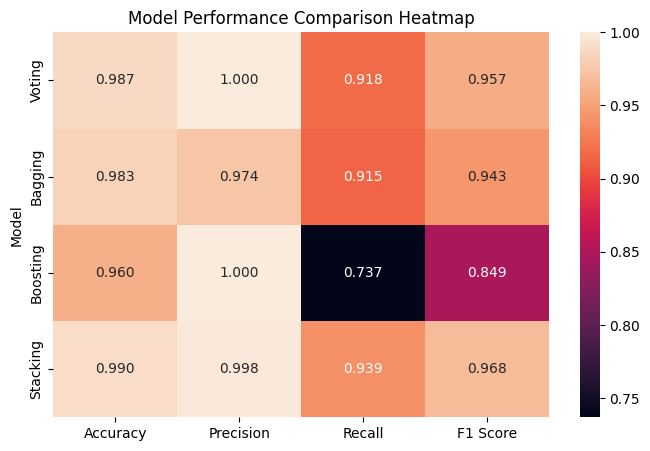

In [117]:
# ================================
# METRICS HEATMAP COMPARISON
# ================================

from sklearn.metrics import precision_score, recall_score, f1_score
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Collect metrics for each model
metrics_data = {
    "Model": ["Voting", "Bagging", "Boosting", "Stacking"],
    
    "Accuracy": [
        accuracy_score(y_test, y_pred_hybrid),
        accuracy_score(y_test, y_pred_bag),
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, y_pred_stack)
    ],
    
    "Precision": [
        precision_score(y_test, y_pred_hybrid),
        precision_score(y_test, y_pred_bag),
        precision_score(y_test, y_pred),
        precision_score(y_test, y_pred_stack)
    ],
    
    "Recall": [
        recall_score(y_test, y_pred_hybrid),
        recall_score(y_test, y_pred_bag),
        recall_score(y_test, y_pred),
        recall_score(y_test, y_pred_stack)
    ],
    
    "F1 Score": [
        f1_score(y_test, y_pred_hybrid),
        f1_score(y_test, y_pred_bag),
        f1_score(y_test, y_pred),
        f1_score(y_test, y_pred_stack)
    ]
}

# Create DataFrame
metrics_df = pd.DataFrame(metrics_data).set_index("Model")

# Plot heatmap
plt.figure(figsize=(8, 5))
sns.heatmap(metrics_df, annot=True, fmt=".3f")
plt.title("Model Performance Comparison Heatmap")
plt.show()

In [118]:
# ================================
# CREATE CONFUSION MATRICES
# ================================

from sklearn.metrics import confusion_matrix

cm_hybrid = confusion_matrix(y_test, y_pred_hybrid)
cm_bag = confusion_matrix(y_test, y_pred_bag)
cm_boost = confusion_matrix(y_test, y_pred)
cm_stack = confusion_matrix(y_test, y_pred_stack)

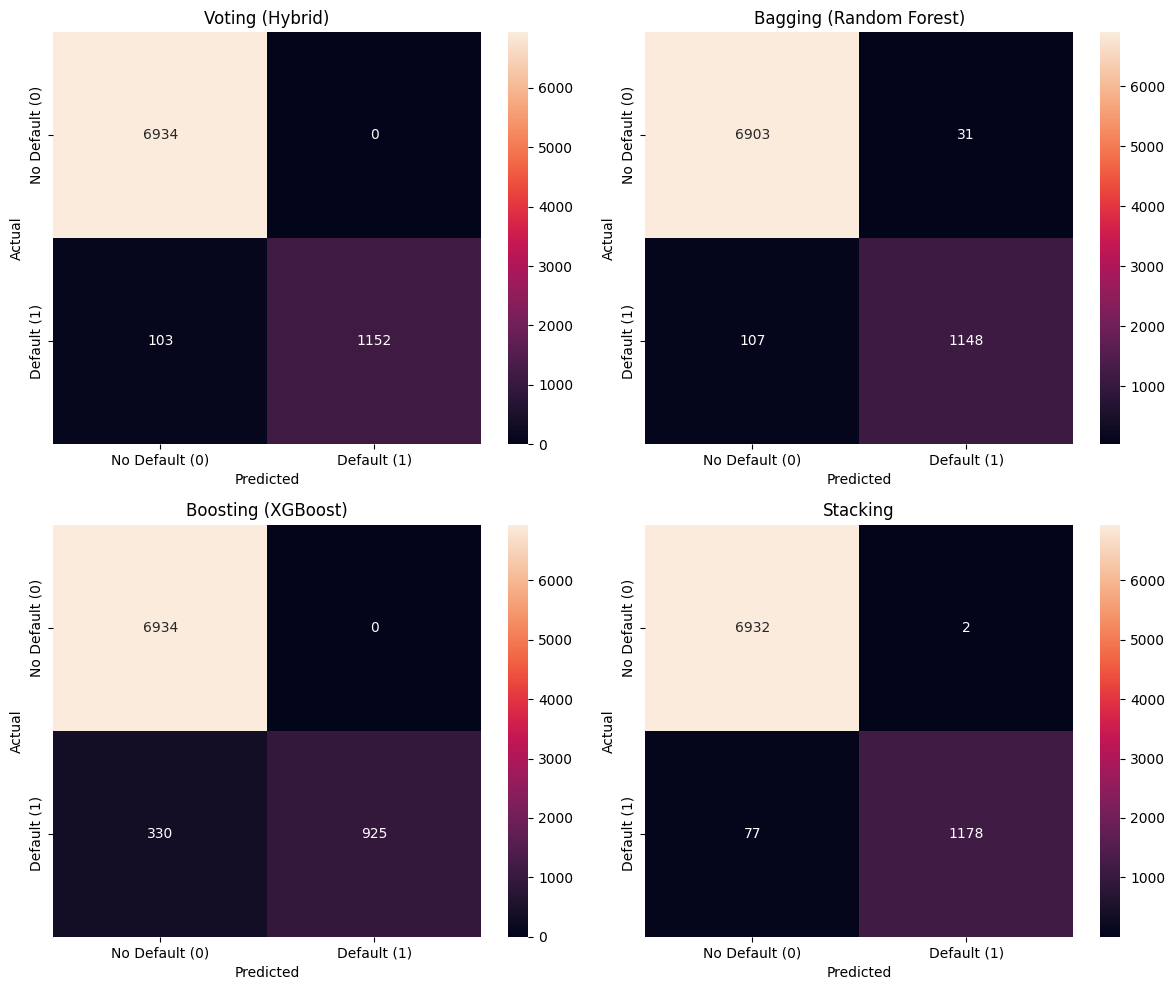

In [119]:


labels = ["No Default (0)", "Default (1)"]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

def plot_cm(cm, title, ax):
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=labels, yticklabels=labels, ax=ax)
    ax.set_title(title)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plot_cm(cm_hybrid, "Voting (Hybrid)", axes[0, 0])
plot_cm(cm_bag, "Bagging (Random Forest)", axes[0, 1])
plot_cm(cm_boost, "Boosting (XGBoost)", axes[1, 0])
plot_cm(cm_stack, "Stacking", axes[1, 1])

plt.tight_layout()
plt.show()

In [120]:
# ================================
# BEST MODEL
# ================================

best_model = results_df_compare.iloc[0]

print("🏆 Best Model:")
print(f"Model: {best_model['Model']}")
print(f"Accuracy: {best_model['Accuracy']:.4f}")

🏆 Best Model:
Model: Stacking
Accuracy: 0.9904


In [126]:
import pandas as pd
import pickle

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from xgboost import XGBClassifier

# Separate features
num_cols = X.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X.select_dtypes(include=['object']).columns

# Pipelines
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])

# Final pipeline
pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('model', XGBClassifier())
])

# Train
pipeline.fit(X, y)

# Save
with open('pipeline.pkl', 'wb') as f:
    pickle.dump(pipeline, f)

In [127]:
import json

columns_data = {
    "numerical": list(num_cols),
    "categorical": list(cat_cols)
}

with open("columns.json", "w") as f:
    json.dump(columns_data, f, indent=4)

In [128]:
import pandas as pd

# Extract model from pipeline
model = pipeline.named_steps['model']

# Feature importance
importance = model.feature_importances_

# Get feature names after preprocessing
feature_names = pipeline.named_steps['preprocessing'].get_feature_names_out()

# Create scorecard
scorecard = pd.DataFrame({
    "feature": feature_names,
    "importance": importance
})

# 🔥 Save with your custom name
scorecard.to_csv("scorecard_of_credits.csv", index=False)

In [130]:
import pandas as pd

# Extract model
model = pipeline.named_steps['model']

# Get importance instead of coef
importance = model.feature_importances_

# Feature names after preprocessing
feature_names = pipeline.named_steps['preprocessing'].get_feature_names_out()

# Create scorecard
scorecard = pd.DataFrame({
    "feature_name": feature_names,
    "credit_score_weight": importance
})

# Save file (your custom name)
scorecard.to_csv("scorecard_of_credits2.csv", index=False)